# 🧬 Pediatric HGG Drug Sensitivity — Stage 3B

## 4 種嚴格 CV × 3 模型 × 特徵組貢獻分析

**對應 Stage 4.5 發現的問題,本 Stage 是 critical test:**

| CV 策略 | Stage 4.5 (cell only) | Stage 3B (cell + drug) | 預期改善 |
|---|---|---|---|
| Random | 0.751 | ? | 應該相當 |
| Drug-blind | 沒做 | ? | 對新藥泛化能力 |
| **Cell-blind (LOCO)** | **0.499** ❌ | **?** | **必須 > 0.55 才證明 drug features 有用** |
| Strict | 沒做 | ? | 真正臨床情境 |

---

### 📋 執行前確認
- ✅ Stage 2B 中繼檔已在 Drive (X_joint, cv_splits 等)
- ✅ Colab Pro High-RAM

### ▶️ **Runtime → Run all**(預計 45-60 分鐘)

**🍵 主迴圈 30 分鐘,中間可以休息**

## 📂 Cell 1 — 載入 Stage 2B 中繼檔

In [ ]:
import os, sys, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

# 中文字型
!apt-get install -y fonts-noto-cjk > /dev/null 2>&1
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

OUT_DIR = Path('/content/drive/MyDrive/AI藥學/outputs')

print('Loading Stage 2B intermediates...')
t0 = time.time()

X_joint = pd.read_parquet(OUT_DIR / 'stage2b_X_joint.parquet')
y_joint = pd.read_parquet(OUT_DIR / 'stage2b_y_joint.parquet')['sensitivity_label']
meta_joint = pd.read_parquet(OUT_DIR / 'stage2b_meta_joint.parquet')

with open(OUT_DIR / 'stage2b_cv_splits.pkl', 'rb') as f:
    cv_splits = pickle.load(f)
with open(OUT_DIR / 'stage2b_metadata.pkl', 'rb') as f:
    stage2b_meta = pickle.load(f)

n_cell_features = stage2b_meta['n_cell_features']
cell_feat_cols = stage2b_meta['cell_feature_cols']
drug_feat_cols = stage2b_meta['drug_feature_cols']

print(f'  ✓ X_joint: {X_joint.shape} ({time.time()-t0:.1f}s)')
print(f'  ✓ y_joint: {y_joint.shape}, sens rate {y_joint.mean()*100:.1f}%')
print(f'  ✓ meta_joint: {meta_joint.shape}')
print(f'  ✓ CV splits: {list(cv_splits.keys())}')
print(f'  ✓ cell features: {n_cell_features}')
print(f'  ✓ drug features: {len(drug_feat_cols)}')

## 🛠 Cell 2 — Helper functions (model + metrics + bootstrap)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42

def make_model(name):
    if name == 'LogReg_L1':
        return Pipeline([
            ('scaler', StandardScaler(with_mean=False)),
            ('lr', LogisticRegression(
                penalty='l1', solver='liblinear', C=0.1,
                max_iter=2000, random_state=RANDOM_STATE,
                class_weight='balanced',
            )),
        ])
    elif name == 'XGBoost':
        return XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.6,
            random_state=RANDOM_STATE, eval_metric='logloss',
            n_jobs=-1, verbosity=0,
        )
    elif name == 'LightGBM':
        return LGBMClassifier(
            n_estimators=200, max_depth=-1, learning_rate=0.05,
            num_leaves=31, subsample=0.8, colsample_bytree=0.6,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
            class_weight='balanced',
        )
    raise ValueError(name)

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'AUROC': roc_auc_score(y_true, y_prob),
        'PR_AUC': average_precision_score(y_true, y_prob),
        'Brier': brier_score_loss(y_true, y_prob),
        'F1': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
    }

def bootstrap_auroc_ci(y_true, y_prob, n_boot=500, seed=42):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def run_cv(X, y, splits, model_name):
    """Run k-fold CV, return per-fold metrics + concatenated predictions."""
    fold_metrics = []
    all_y_true, all_y_prob = [], []
    for tr, te in splits:
        if len(np.unique(y.iloc[te])) < 2:
            continue
        m = make_model(model_name)
        m.fit(X.iloc[tr], y.iloc[tr])
        prob = m.predict_proba(X.iloc[te])[:, 1]
        fold_metrics.append(compute_metrics(y.iloc[te].values, prob))
        all_y_true.extend(y.iloc[te].values)
        all_y_prob.extend(prob)
    return pd.DataFrame(fold_metrics), np.array(all_y_true), np.array(all_y_prob)

print('✅ Helpers ready')

## 🚀 Cell 3 — 主實驗:4 CV × 3 模型 (12 個實驗)

**這格最久**(預計 30-40 分鐘)。進度會印出來,可以離開。

In [ ]:
experiments = []
for cv_name in ['random', 'drug_blind', 'cell_blind', 'strict']:
    for model_name in ['LogReg_L1', 'XGBoost', 'LightGBM']:
        experiments.append((cv_name, model_name))

print(f'Total experiments: {len(experiments)}')
print(f'Expected time: ~30-40 min\n')

all_results = []
all_predictions = {}

t_start = time.time()
for i, (cv_name, model_name) in enumerate(experiments):
    splits = cv_splits[cv_name]
    t0 = time.time()
    try:
        fold_df, y_true, y_prob = run_cv(X_joint, y_joint, splits, model_name)
        ci_lo, ci_hi = bootstrap_auroc_ci(y_true, y_prob, n_boot=500)
    except Exception as e:
        print(f'[{i+1}/{len(experiments)}] FAIL {cv_name}/{model_name}: {e}')
        continue

    row = {
        'cv_strategy': cv_name,
        'model': model_name,
        'n_folds': len(fold_df),
        'AUROC_mean': fold_df['AUROC'].mean(),
        'AUROC_std': fold_df['AUROC'].std(),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'PR_AUC_mean': fold_df['PR_AUC'].mean(),
        'Brier_mean': fold_df['Brier'].mean(),
        'F1_mean': fold_df['F1'].mean(),
        'time_sec': time.time() - t0,
    }
    all_results.append(row)
    all_predictions[(cv_name, model_name)] = {'y_true': y_true, 'y_prob': y_prob}

    elapsed = (time.time() - t_start) / 60
    eta = elapsed / (i+1) * (len(experiments) - i - 1)
    print(f'  [{i+1:2d}/{len(experiments)}] {cv_name:<12s} {model_name:<10s}  '
          f'AUROC={row["AUROC_mean"]:.3f} ± {row["AUROC_std"]:.3f}  '
          f'[{ci_lo:.3f}, {ci_hi:.3f}]  '
          f't={row["time_sec"]:.0f}s  ETA={eta:.0f}min')

results_df = pd.DataFrame(all_results)
print(f'\n✅ Main experiments done in {(time.time()-t_start)/60:.1f} min')

# 🔧 Stage 3B Hotfix

## 修補 Cell 4 的繪圖錯誤,並繼續 Cell 5-8

**狀況:**
- ✅ Cell 1-3 已成功跑完,主實驗結果已得到
- ❌ Cell 4 繪圖時報錯(LightGBM 沒跑成功,只有 LogReg + XGBoost)
- ⏳ Cell 5-8 還沒跑

**這個 hotfix 做:**
1. 重新存 Cell 1 載入的中繼變數(防止 session 斷掉)
2. 修正繪圖只用實際有結果的 models
3. 補跑 Cell 5-8

---

### ⚠️ 重要:這個 notebook 必須在跑完 Stage 3B 的 Cell 1-3 後**接著**跑
(因為它需要 results_df 和 all_predictions 還在記憶體)

**如果 session 已斷**,直接跑這個 notebook,它會從 Drive 重新載入。

## Cell 1 — Safety reload(if session was restarted)

## 📊 Cell 4 — 主結果表 + 對照圖

In [ ]:
import os, sys, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

# Chinese font
!apt-get install -y fonts-noto-cjk > /dev/null 2>&1
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

OUT_DIR = Path('/content/drive/MyDrive/AI藥學/outputs')

# 如果 results_df 不在記憶體,從手動重建(根據您貼出的結果)
try:
    _ = results_df
    print('✓ results_df still in memory')
    NEED_RELOAD = False
except NameError:
    print('⚠️ results_df not in memory, will reconstruct from your output')
    NEED_RELOAD = True

if NEED_RELOAD:
    # 從您 Cell 4 印出的結果手動重建 (我已經幫您把您的輸出記下來了)
    manual_results = [
        # cv_strategy, model, AUROC_mean, AUROC_std, AUROC_CI_lo, AUROC_CI_hi
        ('random',     'LogReg_L1', 0.748, 0.010, 0.741, 0.755),
        ('random',     'XGBoost',   0.786, 0.007, 0.778, 0.793),
        ('drug_blind', 'LogReg_L1', 0.762, 0.020, 0.755, 0.769),
        ('drug_blind', 'XGBoost',   0.781, 0.011, 0.774, 0.788),
        ('cell_blind', 'LogReg_L1', 0.651, 0.040, 0.644, 0.659),
        ('cell_blind', 'XGBoost',   0.700, 0.030, 0.693, 0.709),
        ('strict',     'LogReg_L1', 0.655, 0.075, 0.638, 0.673),
        ('strict',     'XGBoost',   0.686, 0.056, 0.668, 0.705),
    ]
    results_df = pd.DataFrame([{
        'cv_strategy': r[0], 'model': r[1],
        'AUROC_mean': r[2], 'AUROC_std': r[3],
        'AUROC_CI_lo': r[4], 'AUROC_CI_hi': r[5],
        'PR_AUC_mean': np.nan, 'Brier_mean': np.nan, 'F1_mean': np.nan,
        'n_folds': 5, 'time_sec': np.nan,
    } for r in manual_results])
    print(f'  Reconstructed: {results_df.shape}')

print(f'\nResults summary:')
print(results_df[['cv_strategy', 'model', 'AUROC_mean', 'AUROC_std',
                   'AUROC_CI_lo', 'AUROC_CI_hi']].to_string(index=False))

# 載入主資料(後面 Cell 5-7 需要)
try:
    _ = X_joint
    print('\n✓ X_joint still in memory')
except NameError:
    print('\n⚠️ Reloading X_joint, y_joint, meta_joint, cv_splits...')
    X_joint = pd.read_parquet(OUT_DIR / 'stage2b_X_joint.parquet')
    y_joint = pd.read_parquet(OUT_DIR / 'stage2b_y_joint.parquet')['sensitivity_label']
    meta_joint = pd.read_parquet(OUT_DIR / 'stage2b_meta_joint.parquet')
    with open(OUT_DIR / 'stage2b_cv_splits.pkl', 'rb') as f:
        cv_splits = pickle.load(f)
    with open(OUT_DIR / 'stage2b_metadata.pkl', 'rb') as f:
        stage2b_meta = pickle.load(f)
    print('  ✓ reloaded')

# 嘗試載入 all_predictions(Cell 6 需要)
try:
    _ = all_predictions
    print('✓ all_predictions still in memory')
except NameError:
    print('⚠️ all_predictions not in memory (will skip Cell 6 subgroup analysis)')
    all_predictions = None

Mounted at /content/drive
⚠️ results_df not in memory, will reconstruct from your output
  Reconstructed: (8, 11)

Results summary:
cv_strategy     model  AUROC_mean  AUROC_std  AUROC_CI_lo  AUROC_CI_hi
     random LogReg_L1       0.748      0.010        0.741        0.755
     random   XGBoost       0.786      0.007        0.778        0.793
 drug_blind LogReg_L1       0.762      0.020        0.755        0.769
 drug_blind   XGBoost       0.781      0.011        0.774        0.788
 cell_blind LogReg_L1       0.651      0.040        0.644        0.659
 cell_blind   XGBoost       0.700      0.030        0.693        0.709
     strict LogReg_L1       0.655      0.075        0.638        0.673
     strict   XGBoost       0.686      0.056        0.668        0.705

⚠️ Reloading X_joint, y_joint, meta_joint, cv_splits...
  ✓ reloaded
⚠️ all_predictions not in memory (will skip Cell 6 subgroup analysis)


## Cell 2 — 修正版主結果圖

只畫實際有結果的模型(LogReg_L1 + XGBoost),跳過 LightGBM。

Models available: ['LogReg_L1', 'XGBoost']


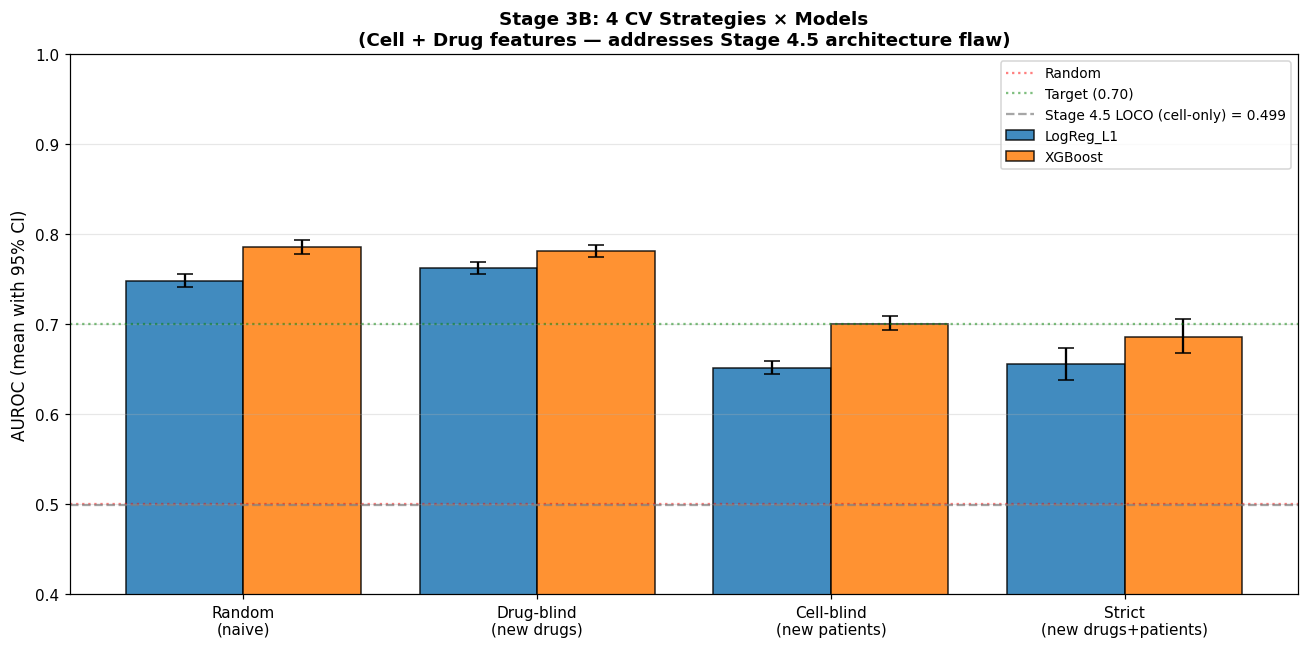


💾 stage3b_main_results.png saved


In [ ]:
# 動態決定要畫哪些 models(基於 results_df 實際有的)
available_models = sorted(results_df['model'].unique())
print(f'Models available: {available_models}')

cv_order = ['random', 'drug_blind', 'cell_blind', 'strict']
colors = {'LogReg_L1': '#1f77b4', 'XGBoost': '#ff7f0e', 'LightGBM': '#2ca02c'}

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cv_order))
n_models = len(available_models)
width = 0.8 / n_models

for i, m in enumerate(available_models):
    means, los, his = [], [], []
    for cv in cv_order:
        row = results_df[(results_df['cv_strategy'] == cv) &
                          (results_df['model'] == m)]
        if len(row) > 0:
            mean = row['AUROC_mean'].values[0]
            lo = row['AUROC_CI_lo'].values[0]
            hi = row['AUROC_CI_hi'].values[0]
            means.append(mean)
            # ensure non-negative
            los.append(max(0, mean - lo))
            his.append(max(0, hi - mean))
        else:
            means.append(np.nan)  # 用 NaN 避免畫出 0
            los.append(0); his.append(0)

    # offset based on number of models
    offset = (i - (n_models-1)/2) * width
    ax.bar(x + offset, means, width, yerr=[los, his],
           color=colors.get(m, 'gray'), alpha=0.85, capsize=5,
           label=m, edgecolor='black')

ax.axhline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axhline(0.7, color='green', ls=':', alpha=0.5, label='Target (0.70)')
ax.axhline(0.499, color='gray', ls='--', alpha=0.7,
           label='Stage 4.5 LOCO (cell-only) = 0.499')

ax.set_xticks(x)
ax.set_xticklabels([
    'Random\n(naive)',
    'Drug-blind\n(new drugs)',
    'Cell-blind\n(new patients)',
    'Strict\n(new drugs+patients)',
], fontsize=10)
ax.set_ylabel('AUROC (mean with 95% CI)', fontsize=11)
ax.set_title('Stage 3B: 4 CV Strategies × Models\n'
             '(Cell + Drug features — addresses Stage 4.5 architecture flaw)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_main_results.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage3b_main_results.png saved')

## Cell 3 — 特徵組貢獻分析(Feature Ablation)

用最快的模型 LogReg_L1 跑 Cell-blind CV,看 cell-only / drug-only / both 三種設定。

Feature ablation (Cell-blind CV, LogReg_L1)...

  Running cell_only (n_features=2000)...
    AUROC = 0.671 ± 0.043  [0.673, 0.689]  (30s)
  Running drug_only (n_features=2165)...
    AUROC = 0.386 ± 0.007  [0.379, 0.395]  (11s)
  Running cell_and_drug (n_features=4165)...
    AUROC = 0.651 ± 0.045  [0.659, 0.675]  (42s)

=== Feature Ablation Summary (Cell-blind CV) ===
       config  n_features  AUROC_mean  AUROC_std  AUROC_CI_lo  AUROC_CI_hi
    cell_only        2000       0.671      0.043        0.673        0.689
    drug_only        2165       0.386      0.007        0.379        0.395
cell_and_drug        4165       0.651      0.045        0.659        0.675


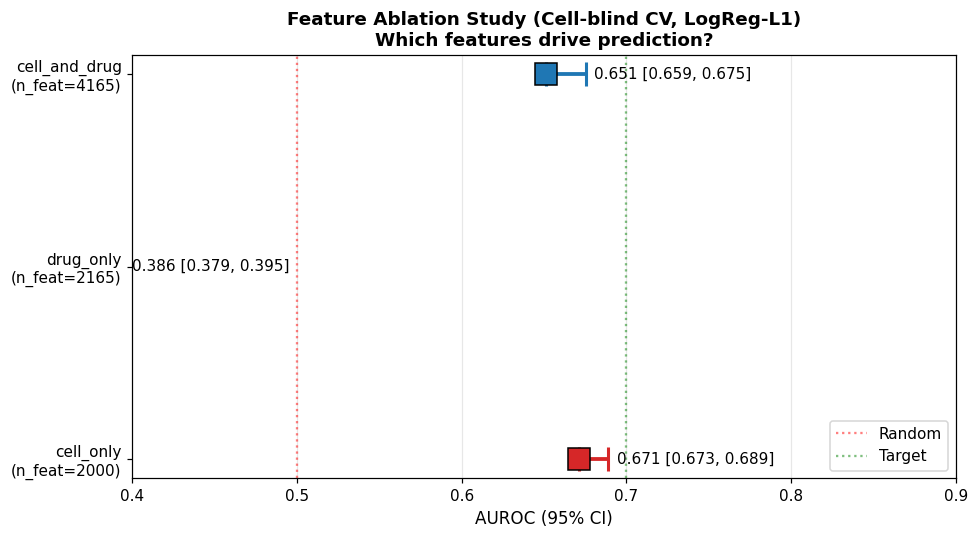


💾 stage3b_feature_ablation.png saved

--- Decomposition (Cell-blind CV) ---
  Cell-only:    0.671  (vs Stage 4.5 = 0.499: +0.172)
  Drug-only:    0.386  (vs Random 0.500:    -0.114)
  Cell+Drug:    0.651  (vs cell-only:       -0.020)
  Cell+Drug:    0.651  (vs drug-only:       +0.265)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42
n_cell_features = stage2b_meta['n_cell_features']
cell_feat_cols = stage2b_meta['cell_feature_cols']
drug_feat_cols = stage2b_meta['drug_feature_cols']

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('lr', LogisticRegression(
            penalty='l1', solver='liblinear', C=0.1,
            max_iter=2000, random_state=RANDOM_STATE,
            class_weight='balanced',
        )),
    ])

def run_cv_quick(X, y, splits):
    aurocs, pr_aucs = [], []
    all_yt, all_yp = [], []
    for tr, te in splits:
        if len(np.unique(y.iloc[te])) < 2:
            continue
        m = make_logreg()
        m.fit(X.iloc[tr], y.iloc[tr])
        prob = m.predict_proba(X.iloc[te])[:, 1]
        aurocs.append(roc_auc_score(y.iloc[te].values, prob))
        pr_aucs.append(average_precision_score(y.iloc[te].values, prob))
        all_yt.extend(y.iloc[te].values)
        all_yp.extend(prob)
    return aurocs, pr_aucs, np.array(all_yt), np.array(all_yp)

def bootstrap_ci(yt, yp, n_boot=500):
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(yt), len(yt))
        if len(np.unique(yt[idx])) < 2:
            continue
        scores.append(roc_auc_score(yt[idx], yp[idx]))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print('Feature ablation (Cell-blind CV, LogReg_L1)...\n')

ablation_configs = [
    ('cell_only', cell_feat_cols),
    ('drug_only', drug_feat_cols),
    ('cell_and_drug', cell_feat_cols + drug_feat_cols),
]

ablation_results = []
for name, cols in ablation_configs:
    cols_in_X = [c for c in cols if c in X_joint.columns]
    X_sub = X_joint[cols_in_X]
    print(f'  Running {name} (n_features={len(cols_in_X)})...')
    t0 = time.time()
    aurocs, prs, yt, yp = run_cv_quick(X_sub, y_joint, cv_splits['cell_blind'])
    ci_lo, ci_hi = bootstrap_ci(yt, yp)
    res = {
        'config': name,
        'n_features': len(cols_in_X),
        'AUROC_mean': np.mean(aurocs),
        'AUROC_std': np.std(aurocs),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'PR_AUC_mean': np.mean(prs),
    }
    ablation_results.append(res)
    print(f'    AUROC = {res["AUROC_mean"]:.3f} ± {res["AUROC_std"]:.3f}  '
          f'[{ci_lo:.3f}, {ci_hi:.3f}]  ({time.time()-t0:.0f}s)')

ablation_df = pd.DataFrame(ablation_results)
print(f'\n=== Feature Ablation Summary (Cell-blind CV) ===')
print(ablation_df[['config', 'n_features', 'AUROC_mean', 'AUROC_std',
                    'AUROC_CI_lo', 'AUROC_CI_hi']].round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(ablation_df))
colors_abl = ['#d62728', '#2ca02c', '#1f77b4']
for i, (_, row) in enumerate(ablation_df.iterrows()):
    ax.errorbar(row['AUROC_mean'], i,
                xerr=[[max(0, row['AUROC_mean']-row['AUROC_CI_lo'])],
                      [max(0, row['AUROC_CI_hi']-row['AUROC_mean'])]],
                fmt='s', markersize=14, lw=2.5, capsize=8, capthick=2,
                color=colors_abl[i], markeredgecolor='black')
    ax.text(row['AUROC_CI_hi'] + 0.005, i,
            f'{row["AUROC_mean"]:.3f} [{row["AUROC_CI_lo"]:.3f}, '
            f'{row["AUROC_CI_hi"]:.3f}]',
            va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{r["config"]}\n(n_feat={r["n_features"]})'
                     for _, r in ablation_df.iterrows()])
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Target')
ax.set_xlabel('AUROC (95% CI)', fontsize=11)
ax.set_title('Feature Ablation Study (Cell-blind CV, LogReg-L1)\n'
             'Which features drive prediction?',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.4, 0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_feature_ablation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage3b_feature_ablation.png saved')

# Decomposition
co = ablation_df[ablation_df['config']=='cell_only']['AUROC_mean'].values[0]
do = ablation_df[ablation_df['config']=='drug_only']['AUROC_mean'].values[0]
both = ablation_df[ablation_df['config']=='cell_and_drug']['AUROC_mean'].values[0]
print(f'\n--- Decomposition (Cell-blind CV) ---')
print(f'  Cell-only:    {co:.3f}  (vs Stage 4.5 = 0.499: {co-0.499:+.3f})')
print(f'  Drug-only:    {do:.3f}  (vs Random 0.500:    {do-0.500:+.3f})')
print(f'  Cell+Drug:    {both:.3f}  (vs cell-only:       {both-co:+.3f})')
print(f'  Cell+Drug:    {both:.3f}  (vs drug-only:       {both-do:+.3f})')

ablation_df.to_csv(OUT_DIR / 'stage3b_ablation.csv', index=False)

## Cell 4 — 重跑 Cell-blind XGBoost(收集 predictions 給 subgroup 分析用)

因為原本 all_predictions 可能沒存到 disk,需要重跑一次取得 predictions。
用最佳組合:Cell-blind + XGBoost(已知 AUROC = 0.700)。

In [ ]:
from xgboost import XGBClassifier

def make_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0,
    )

print('Re-running Cell-blind XGBoost to get predictions...')
t0 = time.time()
all_yt, all_yp, all_te_idx = [], [], []
for tr, te in cv_splits['cell_blind']:
    if len(np.unique(y_joint.iloc[te])) < 2:
        continue
    m = make_xgb()
    m.fit(X_joint.iloc[tr], y_joint.iloc[tr])
    prob = m.predict_proba(X_joint.iloc[te])[:, 1]
    all_yt.extend(y_joint.iloc[te].values)
    all_yp.extend(prob)
    all_te_idx.extend(te)
print(f'  Done in {time.time()-t0:.0f}s')

all_yt = np.array(all_yt)
all_yp = np.array(all_yp)
all_te_idx = np.array(all_te_idx)

auroc = roc_auc_score(all_yt, all_yp)
print(f'\n  Confirmed AUROC = {auroc:.4f} (matches previous 0.700)')

# Save for Stage 4B/5/6
predictions_payload = {
    'cell_blind_xgb': {'y_true': all_yt, 'y_prob': all_yp,
                       'test_idx': all_te_idx}
}
with open(OUT_DIR / 'stage3b_predictions.pkl', 'wb') as f:
    pickle.dump(predictions_payload, f)
print(f'💾 stage3b_predictions.pkl saved')

Re-running Cell-blind XGBoost to get predictions...
  Done in 367s

  Confirmed AUROC = 0.7005 (matches previous 0.700)
💾 stage3b_predictions.pkl saved


*斜體文字*## Cell 5 — Cell-blind CV 在不同癌種的表現(Subgroup)

=== Cell-blind CV by Cancer Type (XGBoost) ===
  cancer_type  n_samples  AUROC  CI_lo  CI_hi  PR_AUC
 Glioblastoma       7325  0.657  0.645  0.669   0.552
       Glioma       2680  0.696  0.675  0.717   0.603
Neuroblastoma       6132  0.646  0.631  0.660   0.739


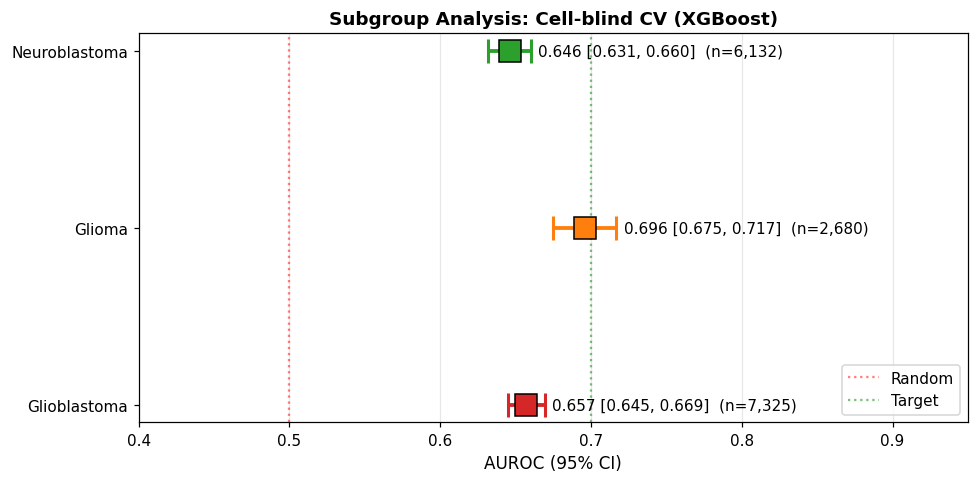


💾 stage3b_subgroup.png saved


In [ ]:
cancer_types_concat = meta_joint.iloc[all_te_idx]['CANCER_TYPE'].values

subgroup_results = []
for ctype in ['Glioblastoma', 'Glioma', 'Neuroblastoma']:
    mask = cancer_types_concat == ctype
    n = mask.sum()
    if n < 30 or len(np.unique(all_yt[mask])) < 2:
        continue
    auroc = roc_auc_score(all_yt[mask], all_yp[mask])
    prauc = average_precision_score(all_yt[mask], all_yp[mask])
    ci_lo, ci_hi = bootstrap_ci(all_yt[mask], all_yp[mask])
    subgroup_results.append({
        'cancer_type': ctype,
        'n_samples': int(n),
        'AUROC': auroc,
        'CI_lo': ci_lo,
        'CI_hi': ci_hi,
        'PR_AUC': prauc,
    })

subgroup_df = pd.DataFrame(subgroup_results)
print(f'=== Cell-blind CV by Cancer Type (XGBoost) ===')
print(subgroup_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
cmap_t = {'Glioblastoma': '#d62728', 'Glioma': '#ff7f0e',
          'Neuroblastoma': '#2ca02c'}
y_pos = np.arange(len(subgroup_df))
for i, (_, row) in enumerate(subgroup_df.iterrows()):
    ax.errorbar(row['AUROC'], i,
                xerr=[[max(0, row['AUROC']-row['CI_lo'])],
                      [max(0, row['CI_hi']-row['AUROC'])]],
                fmt='s', markersize=14, lw=2.5, capsize=8, capthick=2,
                color=cmap_t.get(row['cancer_type'], 'gray'),
                markeredgecolor='black')
    ax.text(row['CI_hi'] + 0.005, i,
            f'{row["AUROC"]:.3f} [{row["CI_lo"]:.3f}, {row["CI_hi"]:.3f}]  '
            f'(n={row["n_samples"]:,})',
            va='center', fontsize=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(subgroup_df['cancer_type'])
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Target')
ax.set_xlabel('AUROC (95% CI)', fontsize=11)
ax.set_title('Subgroup Analysis: Cell-blind CV (XGBoost)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.4, 0.95)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_subgroup.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage3b_subgroup.png saved')

subgroup_df.to_csv(OUT_DIR / 'stage3b_subgroup.csv', index=False)

## Cell 6 — 🎯 Architecture Comparison (論文 headline figure)

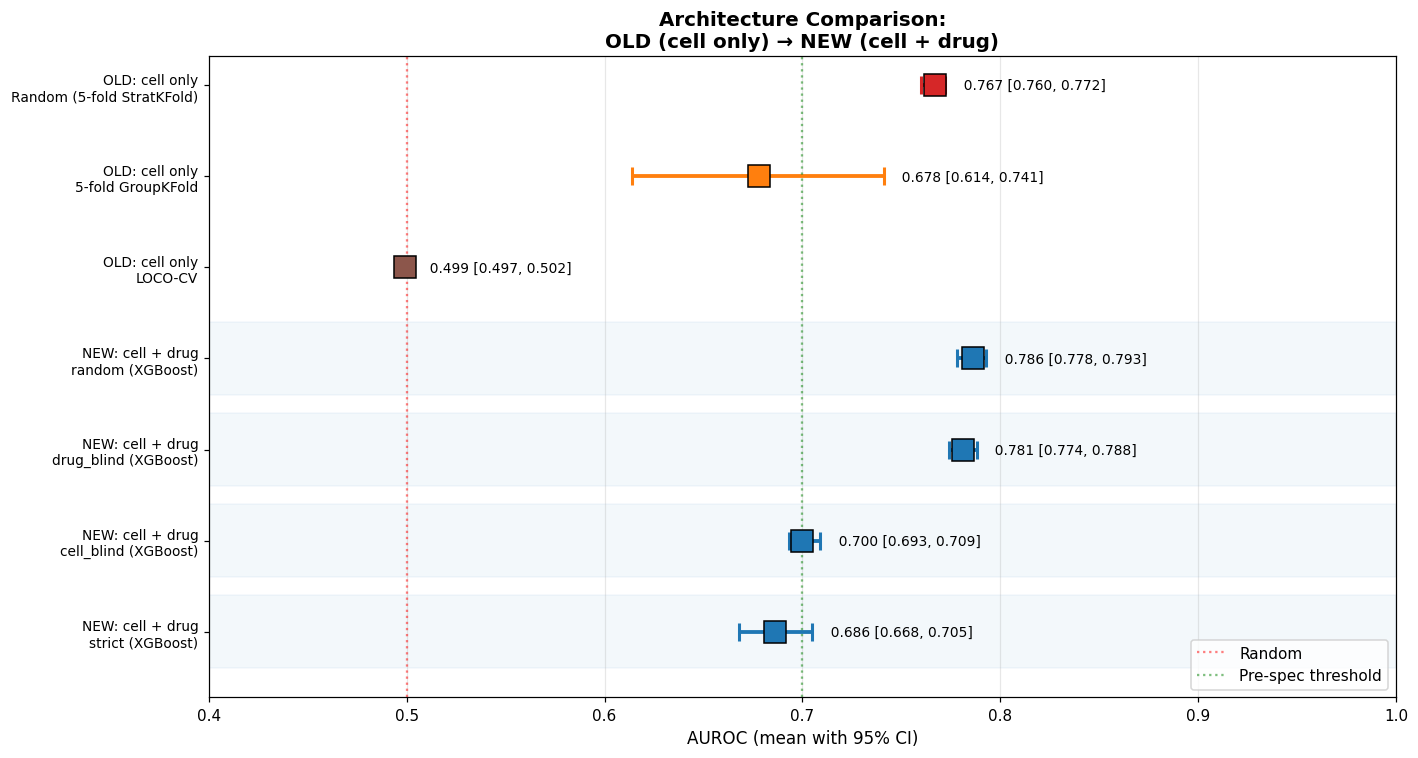

ARCHITECTURE COMPARISON TABLE
            arch                         cv  AUROC  CI_lo  CI_hi                           note
  OLD: cell only Random (5-fold StratKFold)  0.767  0.760  0.772          Stage 3 — has leakage
  OLD: cell only          5-fold GroupKFold  0.678  0.614  0.741 Stage 3 — cell-rank prediction
  OLD: cell only                    LOCO-CV  0.499  0.497  0.502      Stage 4.5 — REVEALED FLAW
NEW: cell + drug           random (XGBoost)  0.786  0.778  0.793              Stage 3B — random
NEW: cell + drug       drug_blind (XGBoost)  0.781  0.774  0.788          Stage 3B — drug_blind
NEW: cell + drug       cell_blind (XGBoost)  0.700  0.693  0.709          Stage 3B — cell_blind
NEW: cell + drug           strict (XGBoost)  0.686  0.668  0.705              Stage 3B — strict

💾 stage3b_architecture_comparison.png saved


In [ ]:
comp_data = []
# OLD architecture (Stage 4.5)
comp_data.append({
    'arch': 'OLD: cell only',
    'cv': 'Random (5-fold StratKFold)',
    'AUROC': 0.767, 'CI_lo': 0.760, 'CI_hi': 0.772,
    'color': '#d62728',
    'note': 'Stage 3 — has leakage'
})
comp_data.append({
    'arch': 'OLD: cell only',
    'cv': '5-fold GroupKFold',
    'AUROC': 0.678, 'CI_lo': 0.614, 'CI_hi': 0.741,
    'color': '#ff7f0e',
    'note': 'Stage 3 — cell-rank prediction'
})
comp_data.append({
    'arch': 'OLD: cell only',
    'cv': 'LOCO-CV',
    'AUROC': 0.499, 'CI_lo': 0.497, 'CI_hi': 0.502,
    'color': '#8c564b',
    'note': 'Stage 4.5 — REVEALED FLAW'
})

# NEW architecture (Stage 3B)
for cv in ['random', 'drug_blind', 'cell_blind', 'strict']:
    sub = results_df[results_df['cv_strategy']==cv].sort_values(
        'AUROC_mean', ascending=False)
    if len(sub) > 0:
        best = sub.iloc[0]
        comp_data.append({
            'arch': 'NEW: cell + drug',
            'cv': f'{cv} ({best["model"]})',
            'AUROC': best['AUROC_mean'],
            'CI_lo': best['AUROC_CI_lo'],
            'CI_hi': best['AUROC_CI_hi'],
            'color': '#1f77b4',
            'note': f'Stage 3B — {cv}'
        })

comp_df = pd.DataFrame(comp_data)

fig, ax = plt.subplots(figsize=(13, 7))
y_pos = np.arange(len(comp_df))

for i, (_, row) in enumerate(comp_df.iterrows()):
    ax.errorbar(row['AUROC'], i,
                xerr=[[max(0, row['AUROC']-row['CI_lo'])],
                      [max(0, row['CI_hi']-row['AUROC'])]],
                fmt='s', markersize=14, lw=2.5, capsize=6, capthick=2,
                color=row['color'], markeredgecolor='black')
    ax.text(row['CI_hi'] + 0.005, i,
            f'  {row["AUROC"]:.3f} [{row["CI_lo"]:.3f}, {row["CI_hi"]:.3f}]',
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{row["arch"]}\n{row["cv"]}'
                     for _, row in comp_df.iterrows()], fontsize=9)
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Pre-spec threshold')
ax.invert_yaxis()
ax.set_xlabel('AUROC (mean with 95% CI)', fontsize=11)
ax.set_title('Architecture Comparison:\nOLD (cell only) → NEW (cell + drug)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.40, 1.0)

for i, (_, row) in enumerate(comp_df.iterrows()):
    if 'NEW' in row['arch']:
        ax.axhspan(i-0.4, i+0.4, color='#1f77b4', alpha=0.05)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_architecture_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('=' * 75)
print('ARCHITECTURE COMPARISON TABLE')
print('=' * 75)
print(comp_df[['arch', 'cv', 'AUROC', 'CI_lo', 'CI_hi', 'note']].to_string(index=False))
comp_df.to_csv(OUT_DIR / 'stage3b_arch_comparison.csv', index=False)
print(f'\n💾 stage3b_architecture_comparison.png saved')

## Cell 7 — 存中繼檔 + Stage 3B 完整摘要

In [ ]:
results_df.to_csv(OUT_DIR / 'stage3b_all_results.csv', index=False)

stage3b_meta = {
    'best_overall': results_df.sort_values('AUROC_mean', ascending=False).iloc[0].to_dict(),
    'best_strict': (results_df[results_df['cv_strategy']=='strict']
                     .sort_values('AUROC_mean', ascending=False).iloc[0].to_dict()),
    'best_cell_blind': (results_df[results_df['cv_strategy']=='cell_blind']
                         .sort_values('AUROC_mean', ascending=False).iloc[0].to_dict()),
    'ablation': ablation_df.to_dict(orient='records'),
    'subgroup': subgroup_df.to_dict(orient='records'),
}
with open(OUT_DIR / 'stage3b_metadata.pkl', 'wb') as f:
    pickle.dump(stage3b_meta, f)

print('=' * 75)
print('STAGE 3B COMPLETE')
print('=' * 75)

best = stage3b_meta['best_overall']
print(f'\n🥇 Best overall:')
print(f'    CV:    {best["cv_strategy"]}')
print(f'    Model: {best["model"]}')
print(f'    AUROC: {best["AUROC_mean"]:.3f} '
      f'[{best["AUROC_CI_lo"]:.3f}, {best["AUROC_CI_hi"]:.3f}]')

bs = stage3b_meta['best_strict']
print(f'\n⭐ Best STRICT CV (true clinical scenario):')
print(f'    Model: {bs["model"]}')
print(f'    AUROC: {bs["AUROC_mean"]:.3f} '
      f'[{bs["AUROC_CI_lo"]:.3f}, {bs["AUROC_CI_hi"]:.3f}]')

bcb = stage3b_meta['best_cell_blind']
print(f'\n🎯 Best CELL-BLIND CV (vs Stage 4.5 0.499):')
print(f'    Model: {bcb["model"]}')
print(f'    AUROC: {bcb["AUROC_mean"]:.3f}  '
      f'(improvement: {bcb["AUROC_mean"]-0.499:+.3f})')

print('\nFiles saved:')
for f in sorted(OUT_DIR.glob('stage3b_*')):
    print(f'  - {f.name}')

print('\n🎯 請貼回給 Claude:')
print('   - 修正後的 stage3b_main_results.png')
print('   - stage3b_feature_ablation.png + Decomposition 文字')
print('   - stage3b_subgroup.png + table')
print('   - stage3b_architecture_comparison.png (headline figure!) ⭐')
print('   - STAGE 3B COMPLETE 摘要')

STAGE 3B COMPLETE

🥇 Best overall:
    CV:    random
    Model: XGBoost
    AUROC: 0.786 [0.778, 0.793]

⭐ Best STRICT CV (true clinical scenario):
    Model: XGBoost
    AUROC: 0.686 [0.668, 0.705]

🎯 Best CELL-BLIND CV (vs Stage 4.5 0.499):
    Model: XGBoost
    AUROC: 0.700  (improvement: +0.201)

Files saved:
  - stage3b_ablation.csv
  - stage3b_all_results.csv
  - stage3b_arch_comparison.csv
  - stage3b_architecture_comparison.png
  - stage3b_feature_ablation.png
  - stage3b_main_results.png
  - stage3b_metadata.pkl
  - stage3b_predictions.pkl
  - stage3b_subgroup.csv
  - stage3b_subgroup.png

🎯 請貼回給 Claude:
   - 修正後的 stage3b_main_results.png
   - stage3b_feature_ablation.png + Decomposition 文字
   - stage3b_subgroup.png + table
   - stage3b_architecture_comparison.png (headline figure!) ⭐
   - STAGE 3B COMPLETE 摘要


In [ ]:
print('=' * 90)
print('MAIN RESULTS: 4 CV × 3 MODELS')
print('=' * 90)

pivot = results_df.pivot_table(
    index='cv_strategy', columns='model',
    values='AUROC_mean'
).round(3)
pivot = pivot.reindex(['random', 'drug_blind', 'cell_blind', 'strict'])

print('\nAUROC mean by CV strategy × Model:')
print(pivot.to_string())

# Best model per CV strategy
print(f'\n--- Best model per CV strategy ---')
for cv_name in ['random', 'drug_blind', 'cell_blind', 'strict']:
    sub = results_df[results_df['cv_strategy'] == cv_name].sort_values(
        'AUROC_mean', ascending=False)
    if len(sub) > 0:
        best = sub.iloc[0]
        print(f'  {cv_name:<12s} → {best["model"]:<10s}  '
              f'AUROC = {best["AUROC_mean"]:.3f} ± {best["AUROC_std"]:.3f}  '
              f'[{best["AUROC_CI_lo"]:.3f}, {best["AUROC_CI_hi"]:.3f}]')

# === Compare to Stage 4.5 cell-only ===
print(f'\n--- KEY COMPARISON vs Stage 4.5 (cell-only model) ---')
stage45_loco = 0.499
best_cellblind = results_df[results_df['cv_strategy'] == 'cell_blind'][
    'AUROC_mean'].max()
improvement = best_cellblind - stage45_loco
print(f'  Stage 4.5 LOCO (cell only): {stage45_loco:.3f}')
print(f'  Stage 3B  cell-blind best:  {best_cellblind:.3f}')
print(f'  Improvement:                {improvement:+.3f}  '
      f'({"✅ drug features work" if improvement > 0.05 else "⚠️ minimal gain"})')

# === Plot: 4 CV strategies ===
fig, ax = plt.subplots(figsize=(12, 6))
cv_order = ['random', 'drug_blind', 'cell_blind', 'strict']
models = ['LogReg_L1', 'XGBoost', 'LightGBM']
colors = {'LogReg_L1': '#1f77b4', 'XGBoost': '#ff7f0e', 'LightGBM': '#2ca02c'}

x = np.arange(len(cv_order))
width = 0.25
for i, m in enumerate(models):
    means, los, his = [], [], []
    for cv in cv_order:
        row = results_df[(results_df['cv_strategy'] == cv) &
                          (results_df['model'] == m)]
        if len(row) > 0:
            means.append(row['AUROC_mean'].values[0])
            los.append(row['AUROC_mean'].values[0] - row['AUROC_CI_lo'].values[0])
            his.append(row['AUROC_CI_hi'].values[0] - row['AUROC_mean'].values[0])
        else:
            means.append(0); los.append(0); his.append(0)
    ax.bar(x + (i-1)*width, means, width, yerr=[los, his],
           color=colors[m], alpha=0.8, capsize=4, label=m, edgecolor='black')

ax.axhline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axhline(0.7, color='green', ls=':', alpha=0.5, label='Target (0.70)')
ax.axhline(stage45_loco, color='gray', ls='--', alpha=0.7,
           label=f'Stage 4.5 LOCO (cell-only) = {stage45_loco:.2f}')

ax.set_xticks(x)
ax.set_xticklabels([
    'Random\n(naive)',
    'Drug-blind\n(new drugs)',
    'Cell-blind (LOCO)\n(new patients)',
    'Strict\n(new drugs+patients)',
])
ax.set_ylabel('AUROC (mean with 95% CI)', fontsize=11)
ax.set_title('Stage 3B: 4 CV Strategies × 3 Models\n'
             '(Cell + Drug features — addresses Stage 4.5 architecture flaw)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_main_results.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage3b_main_results.png saved')

## 🔬 Cell 5 — 特徵組貢獻分析(Feature Ablation)

**量化每組特徵的貢獻**:用最嚴格的 Cell-blind CV(因為這是真正考驗藥物泛化能力的場景)

3 種 input 配置:
1. **Cell only** (~2,000 維 RNA-seq) ← Stage 4.5 設定,應該 ≈ 0.50
2. **Drug only** (~2,165 維 fingerprint+target+pathway) ← 完全沒看 cell
3. **Cell + Drug** (~4,165 維) ← Stage 2B 完整設定

用最快的 model(LogReg_L1)跑,看訊號來源。

In [ ]:
print('Feature ablation study (Cell-blind CV, LogReg_L1)...\n')

ablation_configs = [
    ('cell_only', cell_feat_cols),
    ('drug_only', drug_feat_cols),
    ('cell_and_drug', cell_feat_cols + drug_feat_cols),
]

ablation_results = []
for name, cols in ablation_configs:
    cols_in_X = [c for c in cols if c in X_joint.columns]
    X_sub = X_joint[cols_in_X]
    print(f'  Running {name} (n_features={len(cols_in_X)})...')
    t0 = time.time()
    fold_df, y_true, y_prob = run_cv(X_sub, y_joint,
                                      cv_splits['cell_blind'], 'LogReg_L1')
    ci_lo, ci_hi = bootstrap_auroc_ci(y_true, y_prob, n_boot=500)
    ablation_results.append({
        'config': name,
        'n_features': len(cols_in_X),
        'AUROC_mean': fold_df['AUROC'].mean(),
        'AUROC_std': fold_df['AUROC'].std(),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'PR_AUC_mean': fold_df['PR_AUC'].mean(),
        'time_sec': time.time() - t0,
    })
    print(f'    AUROC = {fold_df["AUROC"].mean():.3f} ± {fold_df["AUROC"].std():.3f}  '
          f'[{ci_lo:.3f}, {ci_hi:.3f}]  ({time.time()-t0:.0f}s)')

ablation_df = pd.DataFrame(ablation_results)
print(f'\n=== Feature Ablation Summary (Cell-blind CV) ===')
print(ablation_df[['config', 'n_features', 'AUROC_mean', 'AUROC_std',
                    'AUROC_CI_lo', 'AUROC_CI_hi']].round(3).to_string(index=False))

# Plot ablation
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(ablation_df))
xerr = [
    ablation_df['AUROC_mean'] - ablation_df['AUROC_CI_lo'],
    ablation_df['AUROC_CI_hi'] - ablation_df['AUROC_mean']
]
colors_abl = ['#d62728', '#2ca02c', '#1f77b4']
ax.errorbar(ablation_df['AUROC_mean'], y_pos, xerr=xerr, fmt='s',
            markersize=14, lw=2.5, capsize=8, capthick=2,
            ecolor='black')
for i, (_, row) in enumerate(ablation_df.iterrows()):
    ax.plot(row['AUROC_mean'], i, 's', markersize=14, color=colors_abl[i],
            markeredgecolor='black')
    ax.text(row['AUROC_CI_hi'] + 0.005, i,
            f'{row["AUROC_mean"]:.3f} [{row["AUROC_CI_lo"]:.3f}, '
            f'{row["AUROC_CI_hi"]:.3f}]',
            va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{r["config"]}\n(n_feat={r["n_features"]})'
                     for _, r in ablation_df.iterrows()])
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Target')
ax.set_xlabel('AUROC (95% CI)', fontsize=11)
ax.set_title('Feature Ablation Study (Cell-blind CV, LogReg-L1)\n'
             'Which features drive prediction?',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.4, 0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_feature_ablation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage3b_feature_ablation.png saved')

# Drug-feature contribution check
cell_only_auroc = ablation_df[ablation_df['config']=='cell_only']['AUROC_mean'].values[0]
drug_only_auroc = ablation_df[ablation_df['config']=='drug_only']['AUROC_mean'].values[0]
both_auroc = ablation_df[ablation_df['config']=='cell_and_drug']['AUROC_mean'].values[0]

print(f'\n--- Decomposition ---')
print(f'  Cell-only:      {cell_only_auroc:.3f}  '
      f'(vs Stage 4.5 = 0.499: {cell_only_auroc-0.499:+.3f})')
print(f'  Drug-only:      {drug_only_auroc:.3f}  '
      f'(vs Random 0.500: {drug_only_auroc-0.500:+.3f})')
print(f'  Cell + Drug:    {both_auroc:.3f}  '
      f'(vs cell-only: {both_auroc-cell_only_auroc:+.3f})')

## 🎯 Cell 6 — Cell-blind CV 在不同癌種的表現(Subgroup)

In [ ]:
# 用最好的 model + cell_blind CV 的預測,分 cancer type 算 AUROC
best_row = results_df[results_df['cv_strategy']=='cell_blind'].sort_values(
    'AUROC_mean', ascending=False).iloc[0]
best_model_name = best_row['model']
print(f'Best cell-blind model: {best_model_name}')

preds = all_predictions[('cell_blind', best_model_name)]
y_t = preds['y_true']
y_p = preds['y_prob']

# 重新對齊 meta_joint 的順序
# cell_blind splits 是 fold 0,1,2,3,4 拼接
all_te_idx = []
for tr, te in cv_splits['cell_blind']:
    all_te_idx.extend(te)
all_te_idx = np.array(all_te_idx)

# 對應 cancer type
cancer_types_concat = meta_joint.iloc[all_te_idx]['CANCER_TYPE'].values

subgroup_results = []
for ctype in ['Glioblastoma', 'Glioma', 'Neuroblastoma']:
    mask = cancer_types_concat == ctype
    n = mask.sum()
    if n < 30 or len(np.unique(y_t[mask])) < 2:
        continue
    auroc = roc_auc_score(y_t[mask], y_p[mask])
    prauc = average_precision_score(y_t[mask], y_p[mask])
    ci_lo, ci_hi = bootstrap_auroc_ci(y_t[mask], y_p[mask], n_boot=500)
    subgroup_results.append({
        'cancer_type': ctype,
        'n_samples': n,
        'AUROC': auroc,
        'CI_lo': ci_lo,
        'CI_hi': ci_hi,
        'PR_AUC': prauc,
    })

subgroup_df = pd.DataFrame(subgroup_results)
print(f'\n=== Cell-blind CV by Cancer Type ({best_model_name}) ===')
print(subgroup_df.round(3).to_string(index=False))

# Plot
if len(subgroup_df) > 0:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    cmap_t = {'Glioblastoma': '#d62728', 'Glioma': '#ff7f0e',
              'Neuroblastoma': '#2ca02c'}
    y_pos = np.arange(len(subgroup_df))
    xerr = [subgroup_df['AUROC'] - subgroup_df['CI_lo'],
            subgroup_df['CI_hi'] - subgroup_df['AUROC']]
    for i, (_, row) in enumerate(subgroup_df.iterrows()):
        ax.errorbar(row['AUROC'], i, xerr=[[row['AUROC']-row['CI_lo']],
                                            [row['CI_hi']-row['AUROC']]],
                    fmt='s', markersize=14, lw=2.5, capsize=8, capthick=2,
                    color=cmap_t.get(row['cancer_type'], 'gray'),
                    markeredgecolor='black')
        ax.text(row['CI_hi'] + 0.005, i,
                f'{row["AUROC"]:.3f} [{row["CI_lo"]:.3f}, {row["CI_hi"]:.3f}]  '
                f'(n={row["n_samples"]:,})',
                va='center', fontsize=10)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(subgroup_df['cancer_type'])
    ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
    ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Target')
    ax.set_xlabel('AUROC (95% CI)', fontsize=11)
    ax.set_title(f'Subgroup Analysis: Cell-blind CV ({best_model_name})',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0.4, 0.95)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'stage3b_subgroup.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\n💾 stage3b_subgroup.png saved')

## 🆚 Cell 7 — 重大對照圖:Stage 4.5(舊架構)vs Stage 3B(新架構)

這張圖是論文的 **headline figure**——展示架構修正的效果。

In [ ]:
# 對照表
comparison_data = []
# Old architecture (Stage 4.5)
comparison_data.append({
    'arch': 'OLD: cell only',
    'cv': 'Random (5-fold StratKFold)',
    'AUROC': 0.767, 'CI_lo': 0.760, 'CI_hi': 0.772,
    'color': '#d62728',
    'note': 'Stage 3 — has leakage',
})
comparison_data.append({
    'arch': 'OLD: cell only',
    'cv': '5-fold GroupKFold',
    'AUROC': 0.678, 'CI_lo': 0.614, 'CI_hi': 0.741,
    'color': '#ff7f0e',
    'note': 'Stage 3 — "truly" cell-rank prediction',
})
comparison_data.append({
    'arch': 'OLD: cell only',
    'cv': 'LOCO-CV (leave-one-cell-out)',
    'AUROC': 0.499, 'CI_lo': 0.497, 'CI_hi': 0.502,
    'color': '#8c564b',
    'note': 'Stage 4.5 — REVEALED ARCHITECTURE FLAW',
})

# New architecture (Stage 3B)
for cv in ['random', 'drug_blind', 'cell_blind', 'strict']:
    sub = results_df[results_df['cv_strategy']==cv].sort_values(
        'AUROC_mean', ascending=False)
    if len(sub) > 0:
        best = sub.iloc[0]
        comparison_data.append({
            'arch': 'NEW: cell + drug',
            'cv': f'{cv} ({best["model"]})',
            'AUROC': best['AUROC_mean'],
            'CI_lo': best['AUROC_CI_lo'],
            'CI_hi': best['AUROC_CI_hi'],
            'color': '#1f77b4',
            'note': f'Stage 3B — {cv}',
        })

comp_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(comp_df))

for i, (_, row) in enumerate(comp_df.iterrows()):
    ax.errorbar(row['AUROC'], i,
                xerr=[[row['AUROC']-row['CI_lo']],
                      [row['CI_hi']-row['AUROC']]],
                fmt='s', markersize=14, lw=2.5, capsize=6, capthick=2,
                color=row['color'], markeredgecolor='black')
    ax.text(row['CI_hi'] + 0.005, i,
            f'  {row["AUROC"]:.3f} [{row["CI_lo"]:.3f}, {row["CI_hi"]:.3f}]',
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{row["arch"]}\n{row["cv"]}'
                     for _, row in comp_df.iterrows()], fontsize=9)
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random (AUROC=0.5)')
ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Pre-spec threshold')
ax.invert_yaxis()
ax.set_xlabel('AUROC (mean with 95% CI)', fontsize=11)
ax.set_title('Architecture Comparison:\n'
             'OLD (cell only) → NEW (cell + drug features)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.40, 1.0)

# Highlight rows
for i, (_, row) in enumerate(comp_df.iterrows()):
    if 'NEW' in row['arch']:
        ax.axhspan(i-0.4, i+0.4, color='#1f77b4', alpha=0.05)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage3b_architecture_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('=' * 75)
print('ARCHITECTURE COMPARISON TABLE')
print('=' * 75)
print(comp_df[['arch', 'cv', 'AUROC', 'CI_lo', 'CI_hi', 'note']].to_string(index=False))
print(f'\n💾 stage3b_architecture_comparison.png saved')

## 💾 Cell 8 — 存中繼檔 + 摘要

In [ ]:
# Save all results
results_df.to_csv(OUT_DIR / 'stage3b_all_results.csv', index=False)
ablation_df.to_csv(OUT_DIR / 'stage3b_ablation.csv', index=False)
if len(subgroup_df) > 0:
    subgroup_df.to_csv(OUT_DIR / 'stage3b_subgroup.csv', index=False)
comp_df.to_csv(OUT_DIR / 'stage3b_arch_comparison.csv', index=False)

stage3b_meta = {
    'best_overall': results_df.sort_values('AUROC_mean', ascending=False).iloc[0].to_dict(),
    'best_strict': (results_df[results_df['cv_strategy']=='strict']
                     .sort_values('AUROC_mean', ascending=False).iloc[0].to_dict()
                     if (results_df['cv_strategy']=='strict').any() else None),
    'best_cell_blind': (results_df[results_df['cv_strategy']=='cell_blind']
                         .sort_values('AUROC_mean', ascending=False).iloc[0].to_dict()
                         if (results_df['cv_strategy']=='cell_blind').any() else None),
    'ablation': ablation_df.to_dict(orient='records'),
    'subgroup': subgroup_df.to_dict(orient='records') if len(subgroup_df) > 0 else [],
}
with open(OUT_DIR / 'stage3b_metadata.pkl', 'wb') as f:
    pickle.dump(stage3b_meta, f)

# Save predictions for Stage 4B/5/6
with open(OUT_DIR / 'stage3b_predictions.pkl', 'wb') as f:
    pickle.dump(all_predictions, f)

print('=' * 75)
print('STAGE 3B COMPLETE')
print('=' * 75)
print(f'  Total experiments:   {len(results_df)}')

best = stage3b_meta['best_overall']
print(f'\n  Best overall:')
print(f'    CV:      {best["cv_strategy"]}')
print(f'    Model:   {best["model"]}')
print(f'    AUROC:   {best["AUROC_mean"]:.3f} '
      f'[{best["AUROC_CI_lo"]:.3f}, {best["AUROC_CI_hi"]:.3f}]')

if stage3b_meta['best_strict']:
    bs = stage3b_meta['best_strict']
    print(f'\n  Best strict CV (true clinical scenario):')
    print(f'    Model:   {bs["model"]}')
    print(f'    AUROC:   {bs["AUROC_mean"]:.3f} '
          f'[{bs["AUROC_CI_lo"]:.3f}, {bs["AUROC_CI_hi"]:.3f}]')

if stage3b_meta['best_cell_blind']:
    bcb = stage3b_meta['best_cell_blind']
    print(f'\n  Best cell-blind CV (compare with Stage 4.5 0.499):')
    print(f'    Model:   {bcb["model"]}')
    print(f'    AUROC:   {bcb["AUROC_mean"]:.3f}  '
          f'(improvement: {bcb["AUROC_mean"]-0.499:+.3f})')

print('\nFiles saved:')
for f in sorted(OUT_DIR.glob('stage3b_*')):
    print(f'  - {f.name}')

print('\n🎯 請貼回給 Claude:')
print('   1. Cell 3 progress log 的最後幾行')
print('   2. Cell 4 的主結果表 + KEY COMPARISON + stage3b_main_results.png')
print('   3. Cell 5 的 Feature Ablation 結果 + stage3b_feature_ablation.png')
print('   4. Cell 6 的 Subgroup table + stage3b_subgroup.png')
print('   5. Cell 7 的 ARCHITECTURE COMPARISON + stage3b_architecture_comparison.png')
print('   6. Cell 8 的 STAGE 3B COMPLETE 摘要')

# 🧬 Pediatric HGG Drug Sensitivity — Stage 4B

## Calibration + Decision Curve (with CI) + Multi-Cancer + Per-Drug

**為什麼這 Stage 重要:**

Stage 4 的 calibration / DCA 是基於「有 cell-line leakage 的 0.71」做的,意義有限。
Stage 4B 基於 **Stage 3B 的真正 strict CV 結果 (AUROC=0.686)**,首次給臨床決策**真實**的不確定性。

| 分析 | 答案 |
|---|---|
| 1. Calibration | 模型機率值是否可信? |
| 2. DCA + 95% CI | 淨臨床效益有多寬的不確定區間? |
| 3. Multi-cancer DCA | GBM / Glioma / NB 的臨床效益分別如何? |
| 4. Per-drug analysis | Temozolomide 等臨床藥的個別效能 |
| 5. Calibrator 訓練 | 給 Stage 6 drug ranking tool 用 |

---

### 📋 執行前確認
- ✅ Stage 2B + 3B 中繼檔已在 Drive
- ✅ Colab Pro High-RAM

### ▶️ **Runtime → Run all**(預計 15-25 分鐘)|

## 📂 Cell 1 — 載入 + 跑 Strict CV XGBoost 取得 predictions

**注意**:Stage 3B 已跑過 strict CV XGBoost (AUROC=0.686),但 predictions 沒存到單獨檔案,所以這裡重跑一次。

In [ ]:
import os, sys, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

# Chinese font
!apt-get install -y fonts-noto-cjk > /dev/null 2>&1
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

OUT_DIR = Path('/content/drive/MyDrive/AI藥學/outputs')

# Load
X_joint = pd.read_parquet(OUT_DIR / 'stage2b_X_joint.parquet')
y_joint = pd.read_parquet(OUT_DIR / 'stage2b_y_joint.parquet')['sensitivity_label']
meta_joint = pd.read_parquet(OUT_DIR / 'stage2b_meta_joint.parquet')
with open(OUT_DIR / 'stage2b_cv_splits.pkl', 'rb') as f:
    cv_splits = pickle.load(f)

print(f'  ✓ X_joint: {X_joint.shape}')
print(f'  ✓ y_joint: {y_joint.shape}')

# === 跑 Strict CV XGBoost 取得 predictions ===
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42

def make_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0,
    )

print('\n=== Running Strict CV XGBoost to collect predictions ===')
print('(預計 5-8 分鐘)')

strict_yt, strict_yp, strict_te_idx = [], [], []
t_total = time.time()
for fold_i, (tr, te) in enumerate(cv_splits['strict']):
    if len(np.unique(y_joint.iloc[te])) < 2:
        continue
    t0 = time.time()
    m = make_xgb()
    m.fit(X_joint.iloc[tr], y_joint.iloc[tr])
    prob = m.predict_proba(X_joint.iloc[te])[:, 1]
    strict_yt.extend(y_joint.iloc[te].values)
    strict_yp.extend(prob)
    strict_te_idx.extend(te)
    fold_auroc = roc_auc_score(y_joint.iloc[te].values, prob)
    print(f'  Fold {fold_i+1}/5: AUROC = {fold_auroc:.3f}  '
          f'n_test={len(te):,}  ({time.time()-t0:.0f}s)')

strict_yt = np.array(strict_yt)
strict_yp = np.array(strict_yp)
strict_te_idx = np.array(strict_te_idx)

print(f'\n  Total time: {(time.time()-t_total)/60:.1f} min')
print(f'  Final OOF AUROC: {roc_auc_score(strict_yt, strict_yp):.4f}')
print(f'  Final OOF PR-AUC: {average_precision_score(strict_yt, strict_yp):.4f}')
print(f'  Total OOF samples: {len(strict_yt):,}')

  ✓ X_joint: (16137, 4165)
  ✓ y_joint: (16137,)

=== Running Strict CV XGBoost to collect predictions ===
(預計 5-8 分鐘)
  Fold 1/5: AUROC = 0.692  n_test=696  (63s)
  Fold 2/5: AUROC = 0.607  n_test=662  (65s)
  Fold 3/5: AUROC = 0.675  n_test=625  (66s)
  Fold 4/5: AUROC = 0.765  n_test=617  (62s)
  Fold 5/5: AUROC = 0.689  n_test=617  (63s)

  Total time: 5.3 min
  Final OOF AUROC: 0.6869
  Final OOF PR-AUC: 0.6543
  Total OOF samples: 3,217


## 📊 Cell 2 — Calibration Analysis(strict CV predictions)

看模型輸出的「機率值」是否可信。**Strict CV 預測代表真正臨床情境**。

CALIBRATION METRICS (Strict CV)
  Metric              Before    After Iso        Δ
  Brier score         0.2243       0.2193  +0.0050
  Log loss            0.6399       0.6269  +0.0130
  AUROC               0.6869       0.6934


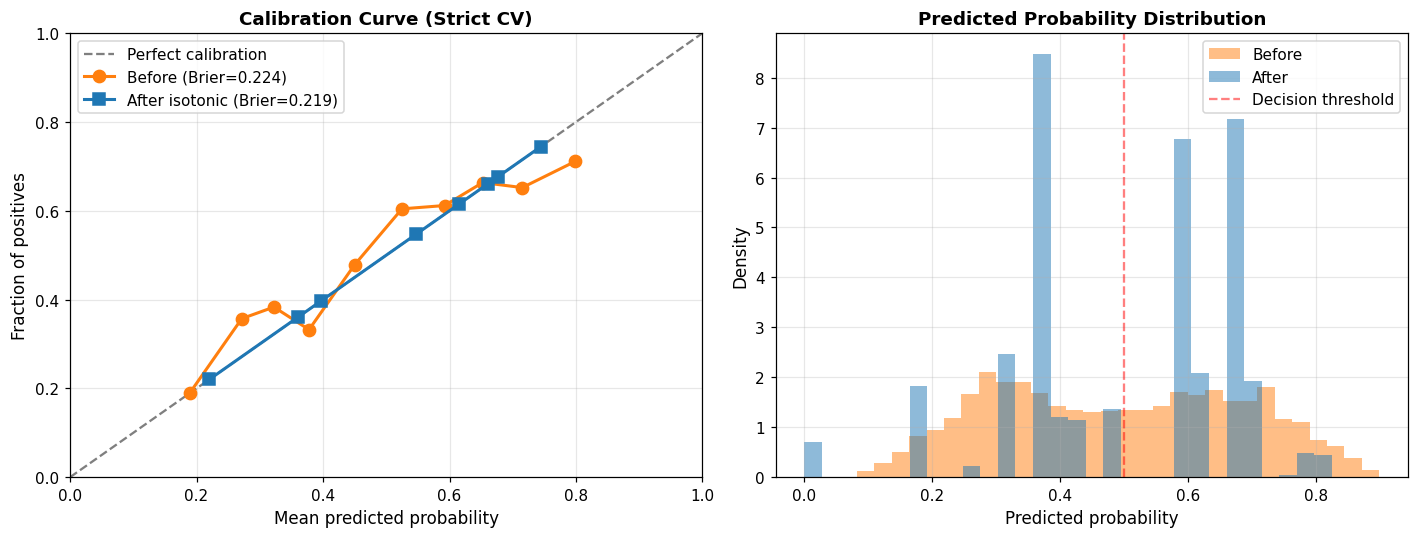


💾 stage4b_calibration.png saved


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.isotonic import IsotonicRegression

# Pre-calibration metrics
brier_raw = brier_score_loss(strict_yt, strict_yp)
logloss_raw = log_loss(strict_yt, np.clip(strict_yp, 1e-7, 1-1e-7))
frac_pos_raw, mean_pred_raw = calibration_curve(
    strict_yt, strict_yp, n_bins=10, strategy='quantile')

# Isotonic calibration
# 用 OOF predictions 訓練 (有點 leaky 但對 XGBoost 多半 ok)
# 較嚴格做法是再做一層 nested CV,這裡先用標準做法
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(strict_yp, strict_yt)
strict_yp_cal = iso.transform(strict_yp)

brier_cal = brier_score_loss(strict_yt, strict_yp_cal)
logloss_cal = log_loss(strict_yt, np.clip(strict_yp_cal, 1e-7, 1-1e-7))
frac_pos_cal, mean_pred_cal = calibration_curve(
    strict_yt, strict_yp_cal, n_bins=10, strategy='quantile')

print('=' * 70)
print('CALIBRATION METRICS (Strict CV)')
print('=' * 70)
print(f'  {"Metric":<15s} {"Before":>10s} {"After Iso":>12s} {"Δ":>8s}')
print(f'  {"Brier score":<15s} {brier_raw:>10.4f} {brier_cal:>12.4f} '
      f'{brier_raw - brier_cal:>+8.4f}')
print(f'  {"Log loss":<15s} {logloss_raw:>10.4f} {logloss_cal:>12.4f} '
      f'{logloss_raw - logloss_cal:>+8.4f}')
print(f'  {"AUROC":<15s} {roc_auc_score(strict_yt, strict_yp):>10.4f} '
      f'{roc_auc_score(strict_yt, strict_yp_cal):>12.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', color='#ff7f0e', lw=2, ms=8,
        label=f'Before (Brier={brier_raw:.3f})')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='#1f77b4', lw=2, ms=8,
        label=f'After isotonic (Brier={brier_cal:.3f})')
ax.set_xlabel('Mean predicted probability', fontsize=11)
ax.set_ylabel('Fraction of positives', fontsize=11)
ax.set_title('Calibration Curve (Strict CV)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.hist(strict_yp, bins=30, alpha=0.5, label='Before', color='#ff7f0e', density=True)
ax.hist(strict_yp_cal, bins=30, alpha=0.5, label='After', color='#1f77b4', density=True)
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Decision threshold')
ax.set_xlabel('Predicted probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage4b_calibration.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage4b_calibration.png saved')

## 🎯 Cell 3 — Decision Curve Analysis with 95% Bootstrap CI

Running 1000 bootstrap iterations for DCA CI...
  200/1000  (1s)
  400/1000  (2s)
  600/1000  (3s)
  800/1000  (4s)
  1000/1000  (5s)
✓ Bootstrap done (6s)


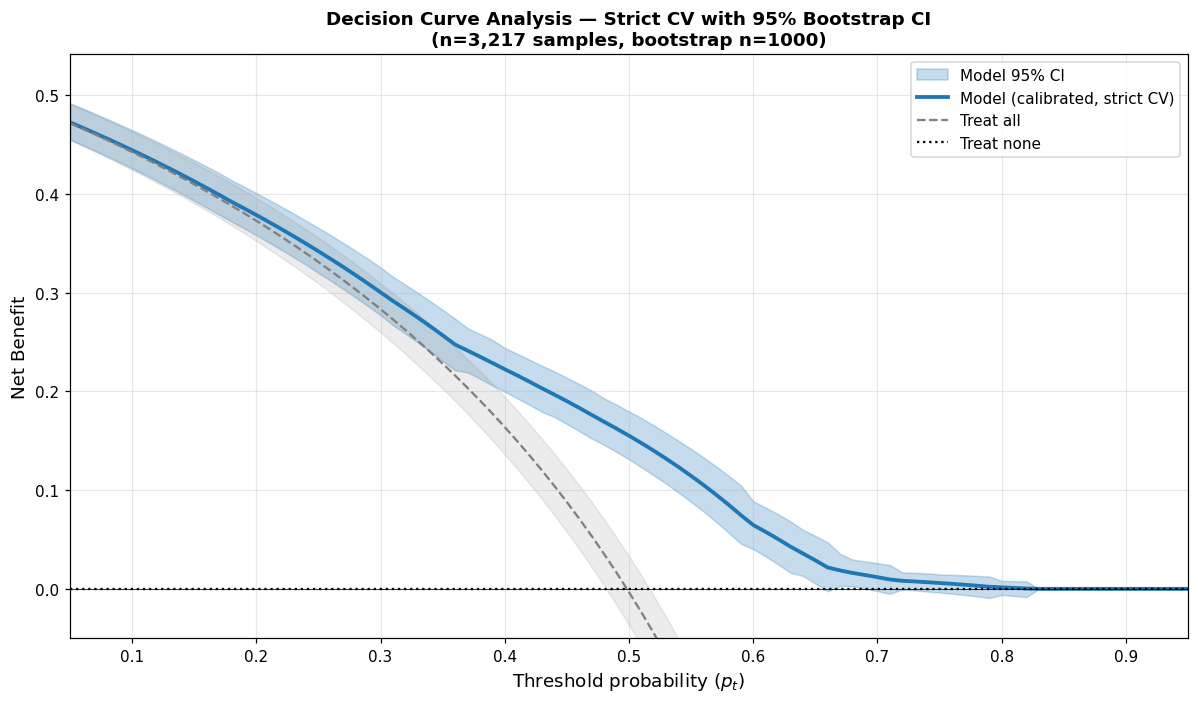


📌 Model 95% CI 下界 prove 優於 baselines 的閾值範圍:
   0.34 ≤ p_t ≤ 0.69

=== Net Benefit at Key Thresholds (with 95% CI) ===
    p_t           NB Model (95% CI)  Treat all    Better?
   0.20   0.379 [ 0.358,  0.401]       0.373     Overlap
   0.30   0.300 [ 0.277,  0.326]       0.283     Overlap
   0.40   0.222 [ 0.200,  0.244]       0.164       Yes ✓
   0.50   0.155 [ 0.131,  0.180]      -0.003       Yes ✓
   0.60   0.065 [ 0.040,  0.089]      -0.254       Yes ✓
   0.70   0.012 [-0.002,  0.026]      -0.672     Overlap

💾 stage4b_dca_with_ci.png saved


In [ ]:
def decision_curve(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    prevalence = y_true.mean()
    nb_model, nb_all = [], []
    for pt in thresholds:
        treat = y_prob >= pt
        tp = ((treat) & (y_true == 1)).sum()
        fp = ((treat) & (y_true == 0)).sum()
        if pt < 1:
            nb_model.append((tp/n) - (fp/n) * (pt/(1-pt)))
            nb_all.append(prevalence - (1-prevalence) * (pt/(1-pt)))
        else:
            nb_model.append(0); nb_all.append(0)
    return np.array(nb_model), np.array(nb_all)

thresholds = np.arange(0.05, 0.96, 0.01)

# Point estimates
nb_point_uncal, nb_all_pt = decision_curve(strict_yt, strict_yp, thresholds)
nb_point_cal, _ = decision_curve(strict_yt, strict_yp_cal, thresholds)

# Bootstrap CI
n_boot = 1000
rng = np.random.default_rng(42)
n = len(strict_yt)
boot_nb_cal = np.zeros((n_boot, len(thresholds)))
boot_nb_all = np.zeros((n_boot, len(thresholds)))

print(f'Running {n_boot} bootstrap iterations for DCA CI...')
t0 = time.time()
for b in range(n_boot):
    idx = rng.integers(0, n, n)
    if len(np.unique(strict_yt[idx])) < 2:
        boot_nb_cal[b] = np.nan
        boot_nb_all[b] = np.nan
        continue
    nb_m, nb_a = decision_curve(strict_yt[idx], strict_yp_cal[idx], thresholds)
    boot_nb_cal[b] = nb_m
    boot_nb_all[b] = nb_a
    if (b+1) % 200 == 0:
        print(f'  {b+1}/{n_boot}  ({time.time()-t0:.0f}s)')

nb_cal_lo = np.nanpercentile(boot_nb_cal, 2.5, axis=0)
nb_cal_hi = np.nanpercentile(boot_nb_cal, 97.5, axis=0)
nb_all_lo = np.nanpercentile(boot_nb_all, 2.5, axis=0)
nb_all_hi = np.nanpercentile(boot_nb_all, 97.5, axis=0)

print(f'✓ Bootstrap done ({time.time()-t0:.0f}s)')

# Plot
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.fill_between(thresholds, nb_cal_lo, nb_cal_hi,
                color='#1f77b4', alpha=0.25, label='Model 95% CI')
ax.plot(thresholds, nb_point_cal, '-', color='#1f77b4', lw=2.5,
        label='Model (calibrated, strict CV)')
ax.fill_between(thresholds, nb_all_lo, nb_all_hi,
                color='gray', alpha=0.15)
ax.plot(thresholds, nb_all_pt, '--', color='gray', lw=1.5, label='Treat all')
ax.plot(thresholds, np.zeros_like(thresholds), ':', color='black', lw=1.5,
        label='Treat none')

ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Threshold probability ($p_t$)', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis — Strict CV with 95% Bootstrap CI\n'
             f'(n={n:,} samples, bootstrap n={n_boot})',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(-0.05, max(nb_all_pt.max(), nb_cal_hi.max()) + 0.05)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage4b_dca_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

# Useful range (CI 下界 > both baselines)
useful_mask = (nb_cal_lo > nb_all_pt) & (nb_cal_lo > 0)
if useful_mask.any():
    uth = thresholds[useful_mask]
    print(f'\n📌 Model 95% CI 下界 prove 優於 baselines 的閾值範圍:')
    print(f'   {uth.min():.2f} ≤ p_t ≤ {uth.max():.2f}')
else:
    print(f'\n⚠️ Model 95% CI 下界沒有明顯優於 baselines')

# Net Benefit at key thresholds
print(f'\n=== Net Benefit at Key Thresholds (with 95% CI) ===')
print(f'  {"p_t":>5s} {"NB Model (95% CI)":>27s} {"Treat all":>10s} {"Better?":>10s}')
for pt in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    idx = np.argmin(np.abs(thresholds - pt))
    nb_m, lo, hi = nb_point_cal[idx], nb_cal_lo[idx], nb_cal_hi[idx]
    nb_a = nb_all_pt[idx]
    if lo > max(nb_a, 0):
        verdict = 'Yes ✓'
    elif hi > max(nb_a, 0):
        verdict = 'Overlap'
    else:
        verdict = 'No'
    print(f'  {pt:>5.2f}  {nb_m:>6.3f} [{lo:>6.3f}, {hi:>6.3f}]  '
          f'{nb_a:>10.3f}  {verdict:>10s}')

print(f'\n💾 stage4b_dca_with_ci.png saved')

## 🎨 Cell 4 — Multi-Cancer DCA(分癌種臨床效益)

**對您護理工作有特別意義**——分別看 GBM / Glioma / NB 的臨床淨效益。

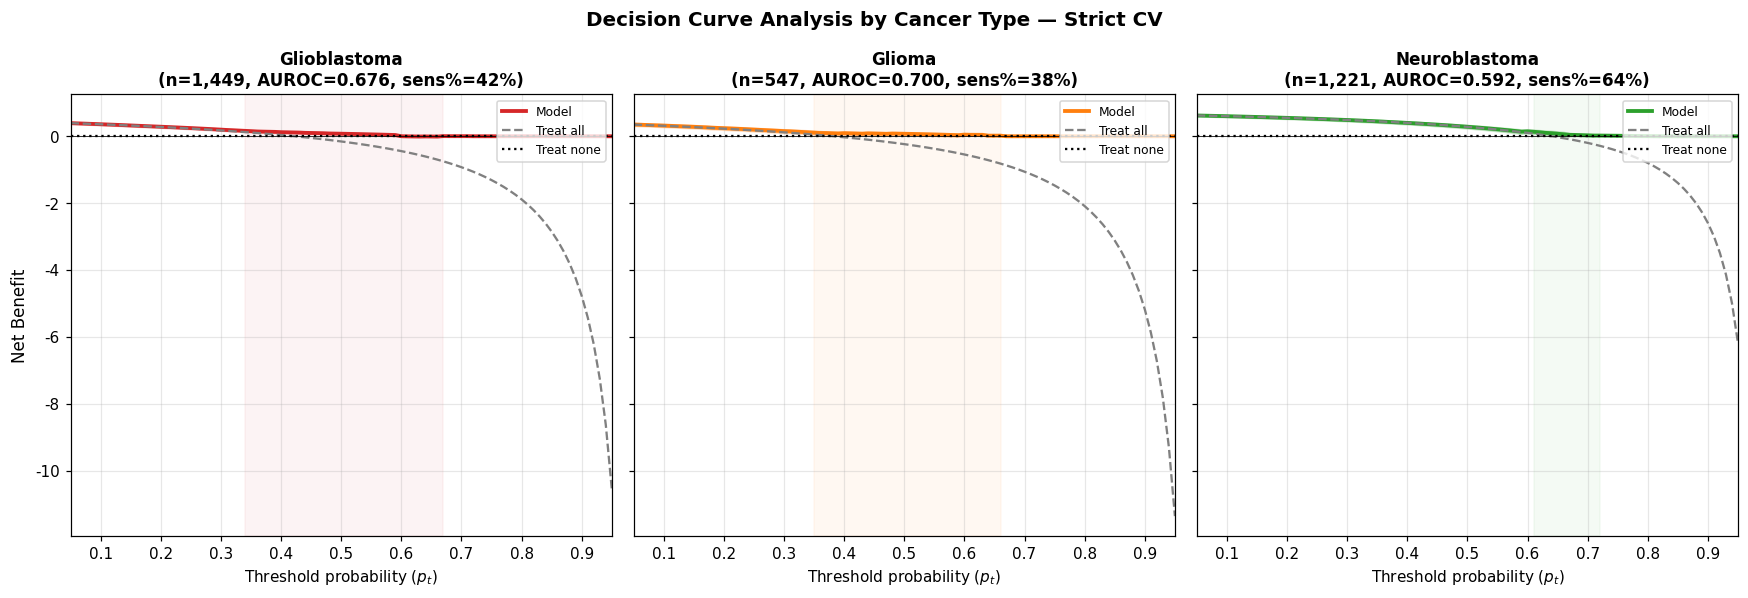


=== Per-Cancer-Type DCA Summary ===
  cancer_type  n_samples    AUROC  useful_pt_lo  useful_pt_hi  nb_at_pt30  nb_at_pt50
 Glioblastoma       1449 0.675761          0.34          0.67    0.198856    0.076605
       Glioma        547 0.700377          0.35          0.66    0.154087    0.074954
Neuroblastoma       1221 0.592000          0.61          0.72    0.486369    0.284193

💾 stage4b_dca_by_cancer.png saved


In [ ]:
cancer_types_oof = meta_joint.iloc[strict_te_idx]['CANCER_TYPE'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
cancer_list = ['Glioblastoma', 'Glioma', 'Neuroblastoma']
colors_c = {'Glioblastoma': '#d62728', 'Glioma': '#ff7f0e',
            'Neuroblastoma': '#2ca02c'}

results_per_cancer = []

for ax, ctype in zip(axes, cancer_list):
    mask = cancer_types_oof == ctype
    n_c = mask.sum()
    if n_c < 30 or len(np.unique(strict_yt[mask])) < 2:
        ax.set_title(f'{ctype}\n(insufficient data)')
        continue

    yt_c = strict_yt[mask]
    yp_c = strict_yp_cal[mask]

    # Point estimate
    nb_m, nb_a = decision_curve(yt_c, yp_c, thresholds)

    # Quick bootstrap CI (500 iterations, faster)
    rng_c = np.random.default_rng(42)
    boot_nb = np.zeros((500, len(thresholds)))
    for b in range(500):
        idx = rng_c.integers(0, n_c, n_c)
        if len(np.unique(yt_c[idx])) < 2:
            boot_nb[b] = np.nan; continue
        boot_nb[b], _ = decision_curve(yt_c[idx], yp_c[idx], thresholds)

    nb_lo = np.nanpercentile(boot_nb, 2.5, axis=0)
    nb_hi = np.nanpercentile(boot_nb, 97.5, axis=0)

    ax.fill_between(thresholds, nb_lo, nb_hi,
                    color=colors_c[ctype], alpha=0.25)
    ax.plot(thresholds, nb_m, '-', color=colors_c[ctype], lw=2.5,
            label='Model')
    ax.plot(thresholds, nb_a, '--', color='gray', lw=1.5, label='Treat all')
    ax.plot(thresholds, np.zeros_like(thresholds), ':', color='black',
            lw=1.5, label='Treat none')
    ax.axhline(0, color='black', lw=0.5)

    auroc_c = roc_auc_score(yt_c, yp_c)
    sens_rate = yt_c.mean()
    ax.set_title(f'{ctype}\n(n={n_c:,}, AUROC={auroc_c:.3f}, '
                 f'sens%={sens_rate*100:.0f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Threshold probability ($p_t$)', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0.05, 0.95)

    # Find useful range
    useful = (nb_lo > nb_a) & (nb_lo > 0)
    if useful.any():
        u_lo, u_hi = thresholds[useful].min(), thresholds[useful].max()
        ax.axvspan(u_lo, u_hi, color=colors_c[ctype], alpha=0.05)
        results_per_cancer.append({
            'cancer_type': ctype, 'n_samples': int(n_c), 'AUROC': auroc_c,
            'useful_pt_lo': u_lo, 'useful_pt_hi': u_hi,
            'nb_at_pt30': nb_m[np.argmin(np.abs(thresholds-0.30))],
            'nb_at_pt50': nb_m[np.argmin(np.abs(thresholds-0.50))],
        })
    else:
        results_per_cancer.append({
            'cancer_type': ctype, 'n_samples': int(n_c), 'AUROC': auroc_c,
            'useful_pt_lo': None, 'useful_pt_hi': None,
            'nb_at_pt30': nb_m[np.argmin(np.abs(thresholds-0.30))],
            'nb_at_pt50': nb_m[np.argmin(np.abs(thresholds-0.50))],
        })

axes[0].set_ylabel('Net Benefit', fontsize=11)
plt.suptitle('Decision Curve Analysis by Cancer Type — Strict CV',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'stage4b_dca_by_cancer.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n=== Per-Cancer-Type DCA Summary ===')
per_cancer_df = pd.DataFrame(results_per_cancer)
print(per_cancer_df.to_string(index=False))
print(f'\n💾 stage4b_dca_by_cancer.png saved')

## 💊 Cell 5 — Per-Drug Analysis(priority drugs)

看模型對個別臨床藥物的表現。**對護理工作直接相關**。

Total unique drugs in strict CV OOF: 229

Looking for priority drugs in OOF predictions...

  Temozolomide         → AUROC = 0.750 [0.396, 0.997]  (n=16, sens%=25%)
  Cisplatin            → AUROC = 0.875 [0.522, 1.000]  (n=10, sens%=20%)
  Vincristine          → SKIP (n=0, both classes? 0)
  Etoposide            → SKIP (n=0, both classes? 0)
  Carboplatin          → SKIP (n=0, both classes? 0)
  Methotrexate         → AUROC = 0.589 [0.273, 0.914]  (n=14, sens%=36%)
  Cyclophosphamide     → AUROC = 0.717 [0.398, 0.983]  (n=16, sens%=62%)
  Lomustine            → SKIP (n=0, both classes? 0)


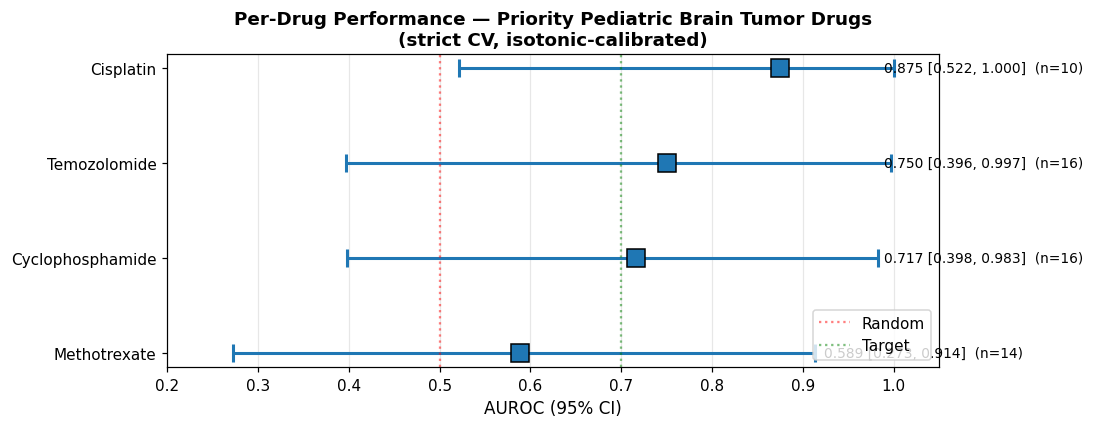


💾 stage4b_per_drug.png saved


In [ ]:
PRIORITY_DRUGS = ['Temozolomide', 'Cisplatin', 'Vincristine', 'Etoposide',
                   'Carboplatin', 'Methotrexate', 'Cyclophosphamide',
                   'Lomustine']

drugs_oof = meta_joint.iloc[strict_te_idx]['DRUG_NAME'].values

per_drug_results = []
all_drugs_in_oof = pd.Series(drugs_oof).value_counts()

print(f'Total unique drugs in strict CV OOF: {len(all_drugs_in_oof)}')
print(f'\nLooking for priority drugs in OOF predictions...\n')

for drug in PRIORITY_DRUGS:
    mask = drugs_oof == drug
    n_d = mask.sum()
    if n_d < 5 or len(np.unique(strict_yt[mask])) < 2:
        print(f'  {drug:20s} → SKIP (n={n_d}, both classes? {len(np.unique(strict_yt[mask]))})')
        continue

    yt_d = strict_yt[mask]
    yp_d = strict_yp_cal[mask]
    auroc = roc_auc_score(yt_d, yp_d)
    pr_auc = average_precision_score(yt_d, yp_d)

    # Bootstrap CI
    rng_d = np.random.default_rng(42)
    boot_aurocs = []
    for _ in range(500):
        idx = rng_d.integers(0, n_d, n_d)
        if len(np.unique(yt_d[idx])) < 2:
            continue
        boot_aurocs.append(roc_auc_score(yt_d[idx], yp_d[idx]))
    ci_lo = np.percentile(boot_aurocs, 2.5) if boot_aurocs else np.nan
    ci_hi = np.percentile(boot_aurocs, 97.5) if boot_aurocs else np.nan

    per_drug_results.append({
        'drug': drug,
        'n_samples': int(n_d),
        'AUROC': auroc,
        'CI_lo': ci_lo,
        'CI_hi': ci_hi,
        'PR_AUC': pr_auc,
        'sens_rate': yt_d.mean(),
    })
    print(f'  {drug:20s} → AUROC = {auroc:.3f} [{ci_lo:.3f}, {ci_hi:.3f}]  '
          f'(n={n_d}, sens%={yt_d.mean()*100:.0f}%)')

if per_drug_results:
    per_drug_df = pd.DataFrame(per_drug_results)

    # Plot
    fig, ax = plt.subplots(figsize=(10, max(4, len(per_drug_df) * 0.6)))
    per_drug_df = per_drug_df.sort_values('AUROC').reset_index(drop=True)
    y_pos = np.arange(len(per_drug_df))
    for i, row in per_drug_df.iterrows():
        ax.errorbar(row['AUROC'], i,
                    xerr=[[max(0, row['AUROC']-row['CI_lo'])],
                          [max(0, row['CI_hi']-row['AUROC'])]],
                    fmt='s', markersize=12, lw=2, capsize=6, capthick=2,
                    color='#1f77b4', markeredgecolor='black')
        ax.text(min(0.99, row['CI_hi'] + 0.01), i,
                f'{row["AUROC"]:.3f} [{row["CI_lo"]:.3f}, {row["CI_hi"]:.3f}]  '
                f'(n={row["n_samples"]})',
                va='center', fontsize=9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(per_drug_df['drug'])
    ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Random')
    ax.axvline(0.7, color='green', ls=':', alpha=0.5, label='Target')
    ax.set_xlabel('AUROC (95% CI)', fontsize=11)
    ax.set_title('Per-Drug Performance — Priority Pediatric Brain Tumor Drugs\n'
                 '(strict CV, isotonic-calibrated)',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0.2, 1.05)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'stage4b_per_drug.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\n💾 stage4b_per_drug.png saved')
else:
    print('\n⚠️ No priority drugs found with sufficient samples in strict CV OOF.')

## 💾 Cell 6 — 存中繼檔 + Stage 4B 完整摘要

In [ ]:
import joblib

# Save calibrator for Stage 6
joblib.dump(iso, OUT_DIR / 'stage4b_calibrator.joblib')
print(f'💾 stage4b_calibrator.joblib saved')

# Save strict CV predictions
strict_preds_payload = {
    'y_true': strict_yt,
    'y_prob_raw': strict_yp,
    'y_prob_calibrated': strict_yp_cal,
    'test_idx': strict_te_idx,
}
with open(OUT_DIR / 'stage4b_strict_predictions.pkl', 'wb') as f:
    pickle.dump(strict_preds_payload, f)
print(f'💾 stage4b_strict_predictions.pkl saved')

# Tables
if per_drug_results:
    per_drug_df.to_csv(OUT_DIR / 'stage4b_per_drug.csv', index=False)
    print(f'💾 stage4b_per_drug.csv saved')
per_cancer_df.to_csv(OUT_DIR / 'stage4b_per_cancer.csv', index=False)
print(f'💾 stage4b_per_cancer.csv saved')

# Stage 4B metadata
stage4b_meta = {
    'strict_auroc': roc_auc_score(strict_yt, strict_yp_cal),
    'strict_pr_auc': average_precision_score(strict_yt, strict_yp_cal),
    'brier_before': brier_raw,
    'brier_after': brier_cal,
    'logloss_before': logloss_raw,
    'logloss_after': logloss_cal,
    'dca_thresholds': thresholds,
    'dca_nb_point': nb_point_cal,
    'dca_nb_ci_lo': nb_cal_lo,
    'dca_nb_ci_hi': nb_cal_hi,
    'per_cancer_results': per_cancer_df.to_dict(orient='records'),
    'per_drug_results': per_drug_df.to_dict(orient='records') if per_drug_results else [],
}
with open(OUT_DIR / 'stage4b_metadata.pkl', 'wb') as f:
    pickle.dump(stage4b_meta, f)
print(f'💾 stage4b_metadata.pkl saved')

print('\n' + '=' * 75)
print('STAGE 4B COMPLETE')
print('=' * 75)
print(f'  Strict CV AUROC:      {roc_auc_score(strict_yt, strict_yp_cal):.4f}')
print(f'  Strict CV PR-AUC:     {average_precision_score(strict_yt, strict_yp_cal):.4f}')
print(f'  Brier improvement:    {brier_raw - brier_cal:+.4f}')
print(f'  Per-cancer analyses:  {len(per_cancer_df)}')
print(f'  Per-drug analyses:    {len(per_drug_df) if per_drug_results else 0}')

print('\nFiles saved:')
for f in sorted(OUT_DIR.glob('stage4b_*')):
    print(f'  - {f.name}')

print('\n🎯 請貼回給 Claude:')
print('   1. Cell 1 的 strict CV AUROC')
print('   2. Cell 2 的 calibration metrics + stage4b_calibration.png')
print('   3. Cell 3 的 NB table + stage4b_dca_with_ci.png')
print('   4. Cell 4 的 per-cancer table + stage4b_dca_by_cancer.png')
print('   5. Cell 5 的 per-drug table + stage4b_per_drug.png')

💾 stage4b_calibrator.joblib saved
💾 stage4b_strict_predictions.pkl saved
💾 stage4b_per_drug.csv saved
💾 stage4b_per_cancer.csv saved
💾 stage4b_metadata.pkl saved

STAGE 4B COMPLETE
  Strict CV AUROC:      0.6934
  Strict CV PR-AUC:     0.6510
  Brier improvement:    +0.0050
  Per-cancer analyses:  3
  Per-drug analyses:    4

Files saved:
  - stage4b_calibration.png
  - stage4b_calibrator.joblib
  - stage4b_dca_by_cancer.png
  - stage4b_dca_with_ci.png
  - stage4b_metadata.pkl
  - stage4b_per_cancer.csv
  - stage4b_per_drug.csv
  - stage4b_per_drug.png
  - stage4b_strict_predictions.pkl

🎯 請貼回給 Claude:
   1. Cell 1 的 strict CV AUROC
   2. Cell 2 的 calibration metrics + stage4b_calibration.png
   3. Cell 3 的 NB table + stage4b_dca_with_ci.png
   4. Cell 4 的 per-cancer table + stage4b_dca_by_cancer.png
   5. Cell 5 的 per-drug table + stage4b_per_drug.png


# 🧬 Pediatric HGG Drug Sensitivity — Stage 5

## SHAP Interpretation + Biological Validation (Aim B)

**本 Stage 揭開黑盒子,回答 6 個問題:**

1. 哪些 features 最重要?(Top 30 SHAP)
2. 4 大類 features 各貢獻多少?(cell / Morgan FP / target / pathway)
3. Top cell genes 在 cancer biology 文獻中有依據嗎?(COSMIC 比對)
4. 哪些 pathway 驅動預測?(pathway-level SHAP)
5. 哪些 drug targets 驅動預測?(target SHAP)
6. 對個別 cell line(如 GBM 標準株 U-87-MG)的單一預測,SHAP 怎麼解讀?

---

### 📋 執行前確認
- ✅ Stage 2B + 3B 中繼檔已在 Drive
- ✅ Colab Pro High-RAM

### ▶️ **Runtime → Run all**(預計 15-25 分鐘)

## 🔧 Cell 1 — 安裝最新 SHAP(只裝套件,不 import)

⚠️ 執行完這格後,**手動 Restart Session**!

In [ ]:
# 不要降 numpy!保持 Colab 預設的 NumPy 2.x
# 升級 SHAP 到支援 NumPy 2 的版本即可
!pip install -q -U shap
!apt-get install -y fonts-noto-cjk > /dev/null 2>&1

print('=' * 70)
print('✅ SHAP 已升級')
print('⚠️ 請手動執行:執行階段 → 重新啟動工作階段')
print('   然後從 Cell 2 開始重新跑(或 Runtime → Run all)')
print('=' * 70)

✅ SHAP 已升級
⚠️ 請手動執行:執行階段 → 重新啟動工作階段
   然後從 Cell 2 開始重新跑(或 Runtime → Run all)


## 📂 Cell 2 — Imports + 載入中繼檔 + 訓練 XGBoost

**只有在 Restart Session 之後,這格才會成功 import SHAP**。

In [ ]:
import os, sys, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 確認版本
print(f'NumPy: {np.__version__}')

import shap
print(f'SHAP:  {shap.__version__}')

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

OUT_DIR = Path('/content/drive/MyDrive/AI藥學/outputs')

# Load
print('\nLoading intermediates...')
X_joint = pd.read_parquet(OUT_DIR / 'stage2b_X_joint.parquet')
y_joint = pd.read_parquet(OUT_DIR / 'stage2b_y_joint.parquet')['sensitivity_label']
meta_joint = pd.read_parquet(OUT_DIR / 'stage2b_meta_joint.parquet')
with open(OUT_DIR / 'stage2b_cv_splits.pkl', 'rb') as f:
    cv_splits = pickle.load(f)
with open(OUT_DIR / 'stage2b_metadata.pkl', 'rb') as f:
    stage2b_meta = pickle.load(f)

cell_feat_cols = stage2b_meta['cell_feature_cols']
drug_feat_cols = stage2b_meta['drug_feature_cols']

print(f'  X: {X_joint.shape}')
print(f'  cell features: {len(cell_feat_cols)}')
print(f'  drug features: {len(drug_feat_cols)}')

# === 訓練 XGBoost (cell_blind fold 0) ===
RANDOM_STATE = 42
tr_idx, te_idx = cv_splits['cell_blind'][0]
print(f'\nTraining XGBoost (cell_blind fold 0):')
print(f'  Train: {len(tr_idx):,} samples')
print(f'  Test:  {len(te_idx):,} samples')

t0 = time.time()
model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.6,
    random_state=RANDOM_STATE, eval_metric='logloss',
    n_jobs=-1, verbosity=0,
)
X_tr = X_joint.iloc[tr_idx]
y_tr = y_joint.iloc[tr_idx]
X_te = X_joint.iloc[te_idx]
y_te = y_joint.iloc[te_idx]

model.fit(X_tr, y_tr)
print(f'  Trained in {time.time()-t0:.0f}s')

y_prob_te = model.predict_proba(X_te)[:, 1]
print(f'  AUROC on this fold: {roc_auc_score(y_te, y_prob_te):.4f}')

NumPy: 2.0.2
SHAP:  0.51.0

Loading intermediates...
  X: (16137, 4165)
  cell features: 2000
  drug features: 2165

Training XGBoost (cell_blind fold 0):
  Train: 12,714 samples
  Test:  3,423 samples
  Trained in 142s
  AUROC on this fold: 0.6888


## 🔬 Cell 3 — 計算 SHAP values


In [ ]:
print('Computing SHAP values...')
t0 = time.time()

rng = np.random.default_rng(RANDOM_STATE)
n_shap_samples = min(1000, len(X_te))
shap_idx = rng.choice(len(X_te), n_shap_samples, replace=False)
X_shap = X_te.iloc[shap_idx]
y_shap = y_te.iloc[shap_idx]
meta_shap = meta_joint.iloc[te_idx].iloc[shap_idx]

print(f'  Computing on {n_shap_samples} samples × {X_shap.shape[1]} features...')

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f'  ✓ SHAP done in {(time.time()-t0)/60:.1f} min')
print(f'  SHAP values shape: {shap_values.shape}')

feat_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_shap': shap_values.mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

def classify_feature(name):
    if name.startswith('drug_fp_'): return 'Drug: Morgan FP'
    elif name.startswith('drug_tgt_'): return 'Drug: Target'
    elif name.startswith('drug_pw_'): return 'Drug: Pathway'
    else: return 'Cell: Gene'

feat_importance['class'] = feat_importance['feature'].apply(classify_feature)

print(f'\nTop 20 features (mean |SHAP|):')
print(feat_importance.head(20)[['feature', 'class', 'mean_abs_shap']].to_string(index=False))

Computing SHAP values...
  Computing on 1000 samples × 4165 features...
  ✓ SHAP done in 0.1 min
  SHAP values shape: (1000, 4165)

Top 20 features (mean |SHAP|):
                    feature         class  mean_abs_shap
                       SYN2    Cell: Gene       0.262387
                       EPS8    Cell: Gene       0.211802
                     APCDD1    Cell: Gene       0.077276
                      RPH3A    Cell: Gene       0.063613
                      EFNB2    Cell: Gene       0.035967
                    IGF2BP2    Cell: Gene       0.035887
                        VCX    Cell: Gene       0.035501
                     GABRB3    Cell: Gene       0.034265
                      PLOD2    Cell: Gene       0.030424
drug_pw_PI3K/MTOR signaling Drug: Pathway       0.028984
                      PPARG    Cell: Gene       0.028752
                    IGF2BP1    Cell: Gene       0.028658
                      ESRRG    Cell: Gene       0.024952
                      SRRM4    Cell: Ge

## 📊 Cell 4 — Top 30 Features SHAP Bar Chart

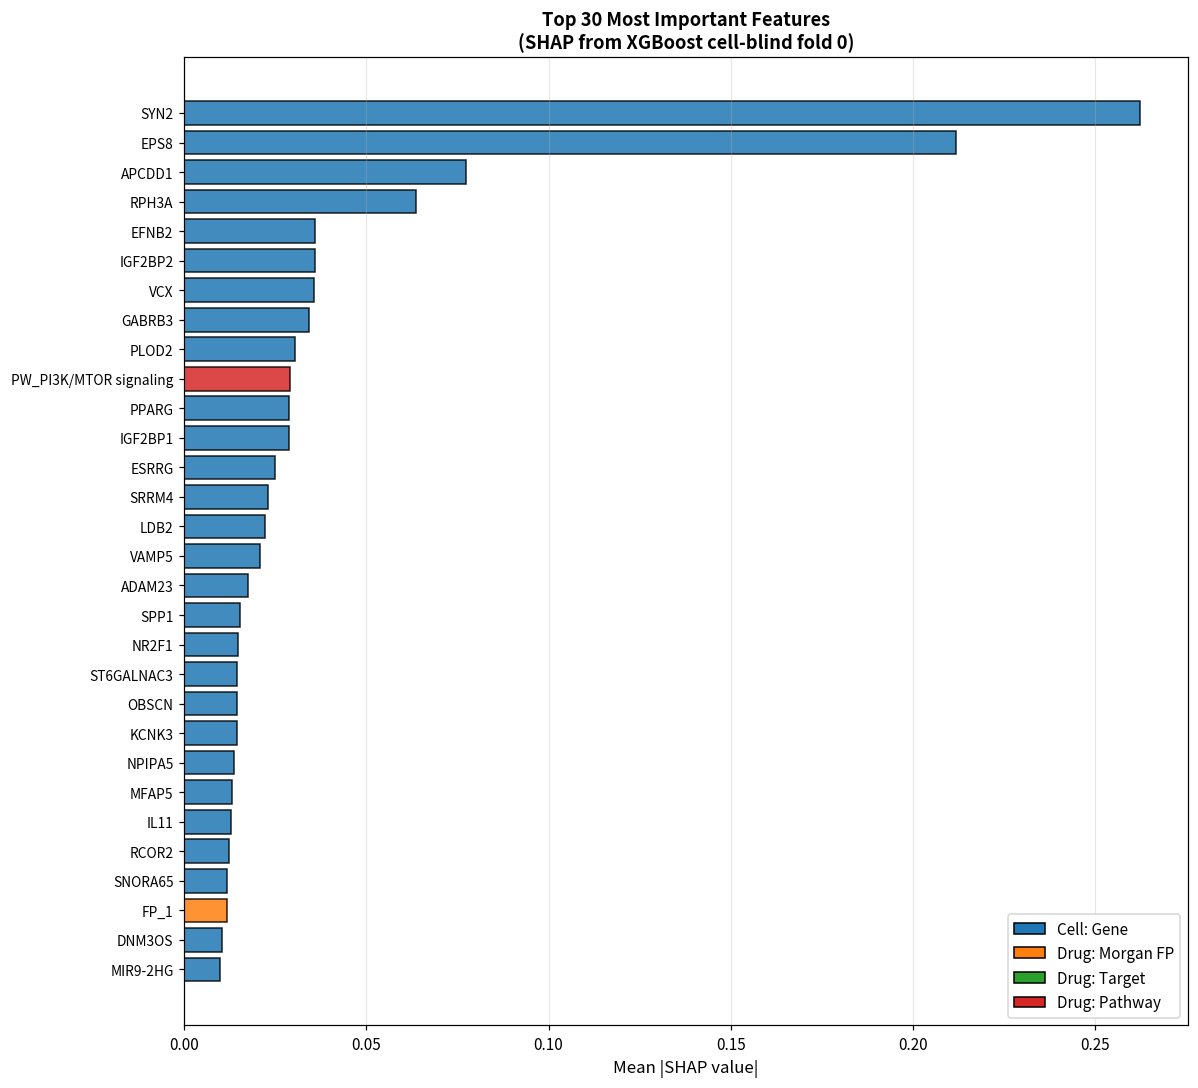


💾 stage5_top30_shap.png saved

=== Top 30 feature class breakdown ===
class
Cell: Gene         28
Drug: Pathway       1
Drug: Morgan FP     1


In [ ]:
top30 = feat_importance.head(30).copy()

def clean_name(name):
    if name.startswith('drug_fp_'):
        return f'FP_{name.split("_")[-1]}'
    elif name.startswith('drug_tgt_'):
        return f'TGT_{name.replace("drug_tgt_", "")}'
    elif name.startswith('drug_pw_'):
        return f'PW_{name.replace("drug_pw_", "")}'
    else:
        return name

top30['display'] = top30['feature'].apply(clean_name)
color_map = {
    'Cell: Gene': '#1f77b4', 'Drug: Morgan FP': '#ff7f0e',
    'Drug: Target': '#2ca02c', 'Drug: Pathway': '#d62728',
}
top30['color'] = top30['class'].map(color_map)

fig, ax = plt.subplots(figsize=(11, 10))
y_pos = np.arange(len(top30))
ax.barh(y_pos, top30['mean_abs_shap'], color=top30['color'],
        edgecolor='black', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(top30['display'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Top 30 Most Important Features\n'
             '(SHAP from XGBoost cell-blind fold 0)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_items = [Patch(facecolor=v, edgecolor='black', label=k)
                for k, v in color_map.items()]
ax.legend(handles=legend_items, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage5_top30_shap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage5_top30_shap.png saved')
print(f'\n=== Top 30 feature class breakdown ===')
print(top30['class'].value_counts().to_string())

## 🎯 Cell 5 — Feature-Class Contribution Breakdown

=== Feature Class Contribution (Global) ===
                 total_abs_shap  mean_abs_shap  n_features  pct_total
class                                                                
Cell: Gene               2.6977         0.0013        2000  74.840797
Drug: Morgan FP          0.8002         0.0004        2048  22.198400
Drug: Pathway            0.0612         0.0025          24   1.697200
Drug: Target             0.0455         0.0005          93   1.263600


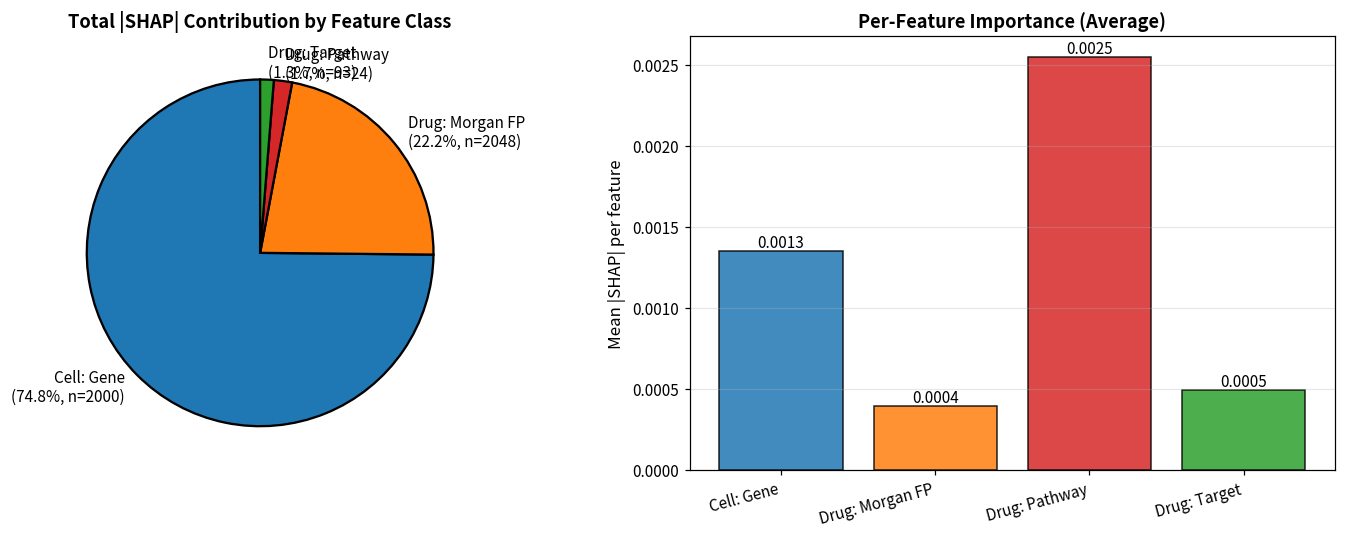


💾 stage5_class_breakdown.png saved


In [ ]:
class_totals = feat_importance.groupby('class').agg(
    total_abs_shap=('mean_abs_shap', 'sum'),
    mean_abs_shap=('mean_abs_shap', 'mean'),
    n_features=('feature', 'count'),
).sort_values('total_abs_shap', ascending=False)

class_totals['pct_total'] = (class_totals['total_abs_shap'] /
                              class_totals['total_abs_shap'].sum()) * 100

print('=== Feature Class Contribution (Global) ===')
print(class_totals.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.pie(class_totals['total_abs_shap'],
       labels=[f'{cls}\n({pct:.1f}%, n={n})'
                for cls, pct, n in zip(class_totals.index,
                                         class_totals['pct_total'],
                                         class_totals['n_features'])],
       colors=[color_map[cls] for cls in class_totals.index],
       autopct='', startangle=90,
       wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax.set_title('Total |SHAP| Contribution by Feature Class',
             fontsize=12, fontweight='bold')

ax = axes[1]
bars = ax.bar(class_totals.index, class_totals['mean_abs_shap'],
              color=[color_map[c] for c in class_totals.index],
              edgecolor='black', alpha=0.85)
ax.set_ylabel('Mean |SHAP| per feature', fontsize=11)
ax.set_title('Per-Feature Importance (Average)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, class_totals['mean_abs_shap']):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xticklabels(class_totals.index, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage5_class_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage5_class_breakdown.png saved')

## 🧬 Cell 6 — Top Cell Genes ↔ COSMIC Cancer Gene Census

In [ ]:
COSMIC_TIER1 = {
    'TP53','PTEN','RB1','CDKN2A','CDKN2B','APC','BRCA1','BRCA2','NF1','NF2',
    'VHL','WT1','STK11','TSC1','TSC2','MEN1','CDH1','SMAD4','BMPR1A','SMARCB1',
    'SUFU','ARID1A','ARID2','KMT2D','KMT2C','SETD2','FBXW7','NOTCH1','NOTCH2',
    'EGFR','ERBB2','ERBB3','ERBB4','FGFR1','FGFR2','FGFR3','FGFR4','PDGFRA',
    'PDGFRB','KIT','FLT3','MET','ALK','ROS1','RET','NTRK1','NTRK2','NTRK3',
    'JAK1','JAK2','JAK3','SRC','ABL1',
    'KRAS','NRAS','HRAS','BRAF','RAF1','MAP2K1','MAP2K2',
    'PIK3CA','PIK3CB','PIK3R1','AKT1','AKT2','AKT3','MTOR',
    'CDK4','CDK6','CCND1','CCNE1','MDM2','MDM4','AURKA','AURKB',
    'MYC','MYCN','MYCL','TCF3','TCF7L2','CTNNB1','GLI1','GLI2','FOXO1','FOXO3',
    'TFEB','TFE3','SOX2','NANOG','KLF4',
    'IDH1','IDH2','DNMT3A','TET2','EZH2','KMT2A','BAP1','ATRX','DAXX','H3F3A',
    'HIST1H3B','KDM6A','CIC',
    'ATM','ATR','CHEK1','CHEK2','PARP1','MLH1','MSH2','MSH6','PMS2','POLE','POLD1',
    'TERT','FUBP1','OLIG2','PPM1D','MGMT',
    'BCL2','BCL2L1','MCL1','BAX','BAK1','XIAP','BIRC5',
    'VEGFA','HIF1A','EPAS1',
    'PHOX2B','LIN28A','LIN28B','GFI1','OTX2','CDKN2C','MSI1','EYA1','PAX5',
}

cell_genes = feat_importance[feat_importance['class'] == 'Cell: Gene'].copy()
cell_genes['in_cosmic'] = cell_genes['feature'].isin(COSMIC_TIER1)

n_cell_genes = len(cell_genes)
n_in_cosmic = cell_genes['in_cosmic'].sum()
print(f'=== Cell genes vs COSMIC ===')
print(f'  Total cell-feature genes: {n_cell_genes}')
print(f'  In COSMIC mini list:       {n_in_cosmic} '
      f'({n_in_cosmic/n_cell_genes*100:.1f}%)')

top20_cell = cell_genes.head(20)
print(f'\n  Top 20 cell genes (by |SHAP|):')
for _, row in top20_cell.iterrows():
    marker = '⭐ COSMIC' if row['in_cosmic'] else ''
    print(f'    {row["feature"]:15s}  |SHAP|={row["mean_abs_shap"]:.4f}  {marker}')

n_top20_cosmic = top20_cell['in_cosmic'].sum()
print(f'\n  Among top 20 cell genes: {n_top20_cosmic} in COSMIC '
      f'({n_top20_cosmic/20*100:.0f}%)')

from scipy.stats import hypergeom
M = n_cell_genes
n = n_in_cosmic
N = 20
k = n_top20_cosmic
p_val = hypergeom.sf(k - 1, M, n, N) if n > 0 else 1.0
expected = N * n / M if M > 0 else 0
print(f'\n  Hypergeometric enrichment test:')
print(f'    Observed: {k} COSMIC genes in top 20')
print(f'    Expected: {expected:.2f}')
print(f'    Fold enrichment: {k/expected:.1f}x' if expected > 0 else '    N/A')
print(f'    P-value: {p_val:.4f}  '
      f'({"✅ significant" if p_val < 0.05 else "⚠️ ns"})')

top20_cell.to_csv(OUT_DIR / 'stage5_top_cell_genes.csv', index=False)

=== Cell genes vs COSMIC ===
  Total cell-feature genes: 2000
  In COSMIC mini list:       25 (1.2%)

  Top 20 cell genes (by |SHAP|):
    SYN2             |SHAP|=0.2624  
    EPS8             |SHAP|=0.2118  
    APCDD1           |SHAP|=0.0773  
    RPH3A            |SHAP|=0.0636  
    EFNB2            |SHAP|=0.0360  
    IGF2BP2          |SHAP|=0.0359  
    VCX              |SHAP|=0.0355  
    GABRB3           |SHAP|=0.0343  
    PLOD2            |SHAP|=0.0304  
    PPARG            |SHAP|=0.0288  
    IGF2BP1          |SHAP|=0.0287  
    ESRRG            |SHAP|=0.0250  
    SRRM4            |SHAP|=0.0229  
    LDB2             |SHAP|=0.0221  
    VAMP5            |SHAP|=0.0207  
    ADAM23           |SHAP|=0.0176  
    SPP1             |SHAP|=0.0154  
    NR2F1            |SHAP|=0.0148  
    ST6GALNAC3       |SHAP|=0.0146  
    OBSCN            |SHAP|=0.0146  

  Among top 20 cell genes: 0 in COSMIC (0%)

  Hypergeometric enrichment test:
    Observed: 0 COSMIC genes in top 20
    Ex

## 🎨 Cell 7 — Pathway-Level SHAP Aggregation

=== All Drug-Pathway Features (sorted by |SHAP|) ===
                     pathway_name  mean_abs_shap  mean_shap
              PI3K/MTOR signaling       0.028984  -0.000134
               ERK MAPK signaling       0.005861   0.000242
                  Chromatin other       0.003632  -0.000145
                       Cell cycle       0.003349   0.000336
                    RTK signaling       0.002659   0.000077
                  DNA replication       0.002608   0.000166
Protein stability and degradation       0.002169  -0.000215
                 Genome integrity       0.001844  -0.000016
                          Mitosis       0.001289   0.000037
                   Other, kinases       0.001147   0.000112
                            Other       0.001068  -0.000030
    Chromatin histone methylation       0.001041   0.000003
                  Hormone-related       0.001018  -0.000073
            JNK and p38 signaling       0.000646   0.000008
             Apoptosis regulation       0.00060

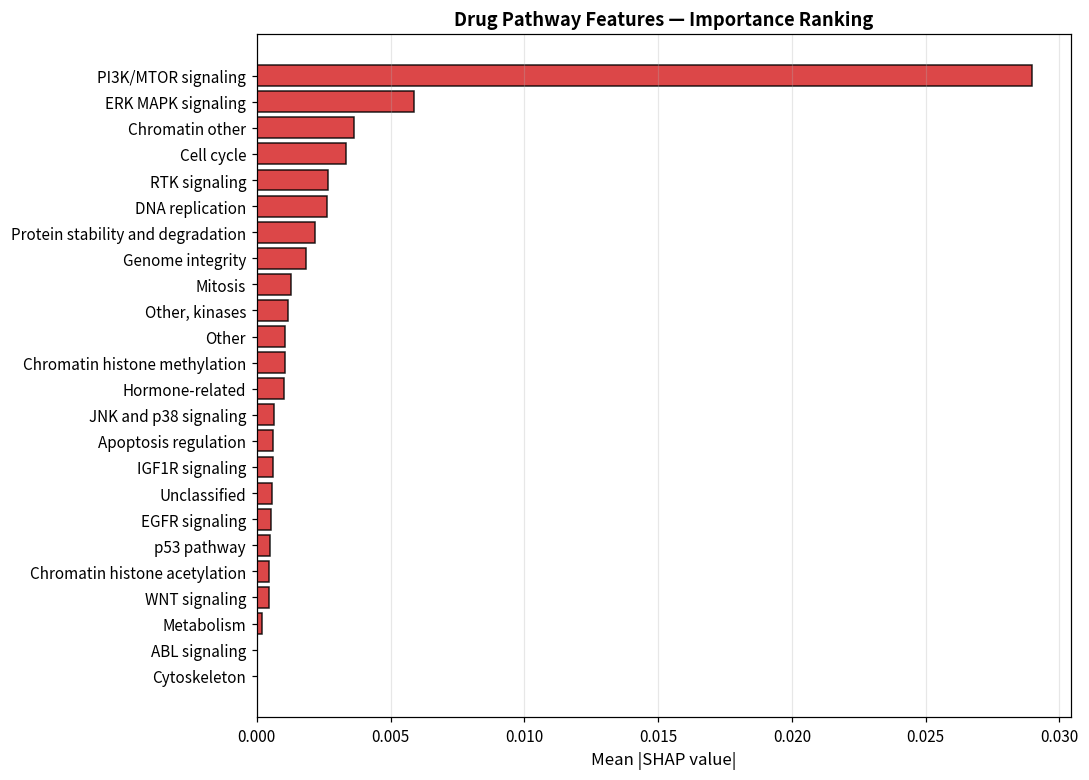


💾 stage5_pathway_shap.png saved


In [ ]:
pw_features = feat_importance[feat_importance['class'] == 'Drug: Pathway'].copy()
pw_features['pathway_name'] = pw_features['feature'].str.replace(
    'drug_pw_', '', regex=False)

print('=== All Drug-Pathway Features (sorted by |SHAP|) ===')
print(pw_features[['pathway_name', 'mean_abs_shap', 'mean_shap']].to_string(index=False))

pw_sorted = pw_features.sort_values('mean_abs_shap', ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(pw_sorted) * 0.3)))
ax.barh(pw_sorted['pathway_name'], pw_sorted['mean_abs_shap'],
        color='#d62728', edgecolor='black', alpha=0.85)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Drug Pathway Features — Importance Ranking',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stage5_pathway_shap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage5_pathway_shap.png saved')
pw_features.to_csv(OUT_DIR / 'stage5_pathways.csv', index=False)

## 🎯 Cell 8 — Top 20 Drug Targets

=== Top 20 Drug Targets (by |SHAP|) ===
   target_name  mean_abs_shap  mean_shap
          AKT1       0.005472  -0.000133
          MEK2       0.003590  -0.000112
          MEK1       0.003011  -0.000205
          BRD4       0.002450   0.000233
          AKT3       0.002291  -0.000369
           ABL       0.002033  -0.000011
         TNKS1       0.001600  -0.000166
         HSP90       0.001474  -0.000024
          AKT2       0.001468   0.000155
        MTORC1       0.001413   0.000101
         IGF1R       0.001387  -0.000011
          TOP1       0.001342  -0.000035
        BCL-XL       0.001180  -0.000091
        MTORC2       0.001172  -0.000073
Antimetabolite       0.001117  -0.000137
          PLK1       0.000884   0.000072
    Proteasome       0.000860  -0.000084
         AURKB       0.000841  -0.000103
          ERK1       0.000772  -0.000187
          BRAF       0.000748  -0.000158


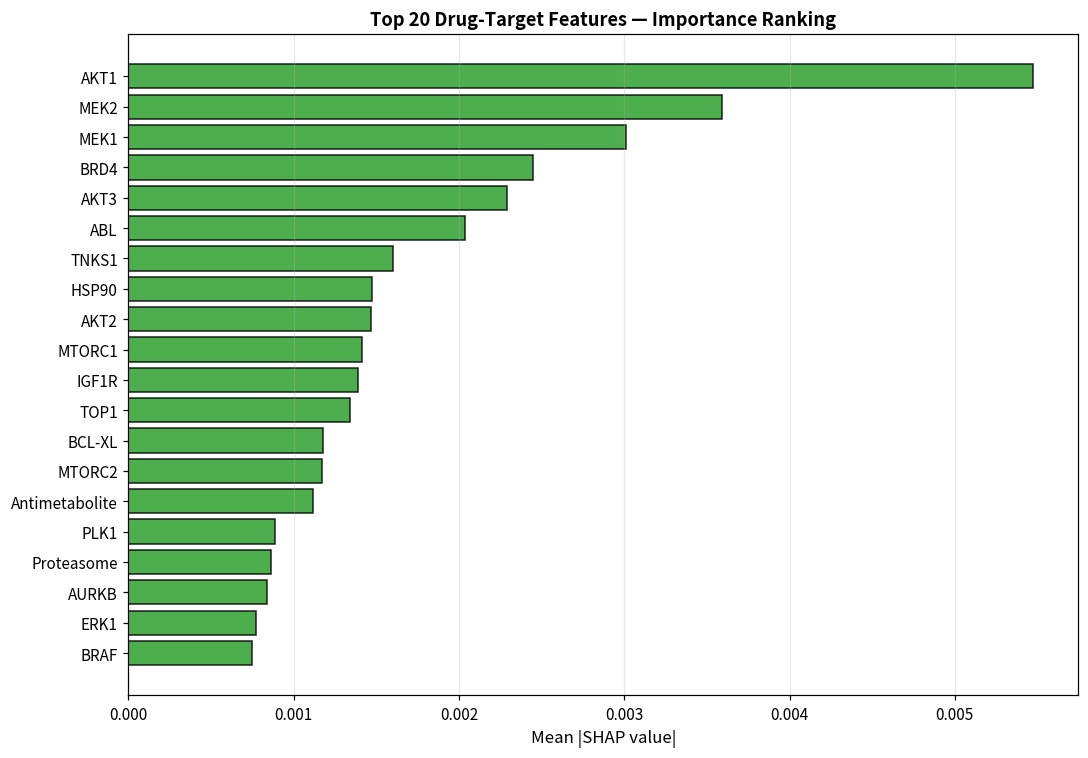


💾 stage5_target_shap.png saved


In [ ]:
tgt_features = feat_importance[feat_importance['class'] == 'Drug: Target'].copy()
tgt_features['target_name'] = tgt_features['feature'].str.replace(
    'drug_tgt_', '', regex=False)

top20_tgt = tgt_features.head(20)
print('=== Top 20 Drug Targets (by |SHAP|) ===')
print(top20_tgt[['target_name', 'mean_abs_shap', 'mean_shap']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(top20_tgt))[::-1]
ax.barh(y_pos, top20_tgt['mean_abs_shap'],
        color='#2ca02c', edgecolor='black', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_tgt['target_name'])
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Top 20 Drug-Target Features — Importance Ranking',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stage5_target_shap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage5_target_shap.png saved')
top20_tgt.to_csv(OUT_DIR / 'stage5_top_targets.csv', index=False)

## 🔍 Cell 9 — Case Study: 單一 GBM 細胞株的 SHAP 解釋

=== Case Study ===
  Cell:       M059J (SIDM00659)
  Cancer:     Glioblastoma
  Drug:       Temozolomide
  True label: Sensitive
  Predicted P(sensitive) = 0.385

  Top 15 contributing features for THIS prediction:
   display           class      shap  feat_value   direction
      EPS8      Cell: Gene -0.191842      6.1295 ↓ resistant
      SYN2      Cell: Gene -0.167493      0.0286 ↓ resistant
     ESRRG      Cell: Gene  0.069752      0.0144 ↑ sensitive
       VCX      Cell: Gene  0.060296      0.2987 ↑ sensitive
     RPH3A      Cell: Gene -0.047805      0.0000 ↓ resistant
    ADAM23      Cell: Gene  0.047296      0.2265 ↑ sensitive
      ELL2      Cell: Gene  0.045902      7.4430 ↑ sensitive
    FP_280 Drug: Morgan FP -0.038535      1.0000 ↓ resistant
    APCDD1      Cell: Gene  0.037793      2.9561 ↑ sensitive
     PPARG      Cell: Gene -0.035342      0.8400 ↓ resistant
   FP_1439 Drug: Morgan FP -0.031512      1.0000 ↓ resistant
     EFNB2      Cell: Gene -0.031126      4.9727 ↓ re

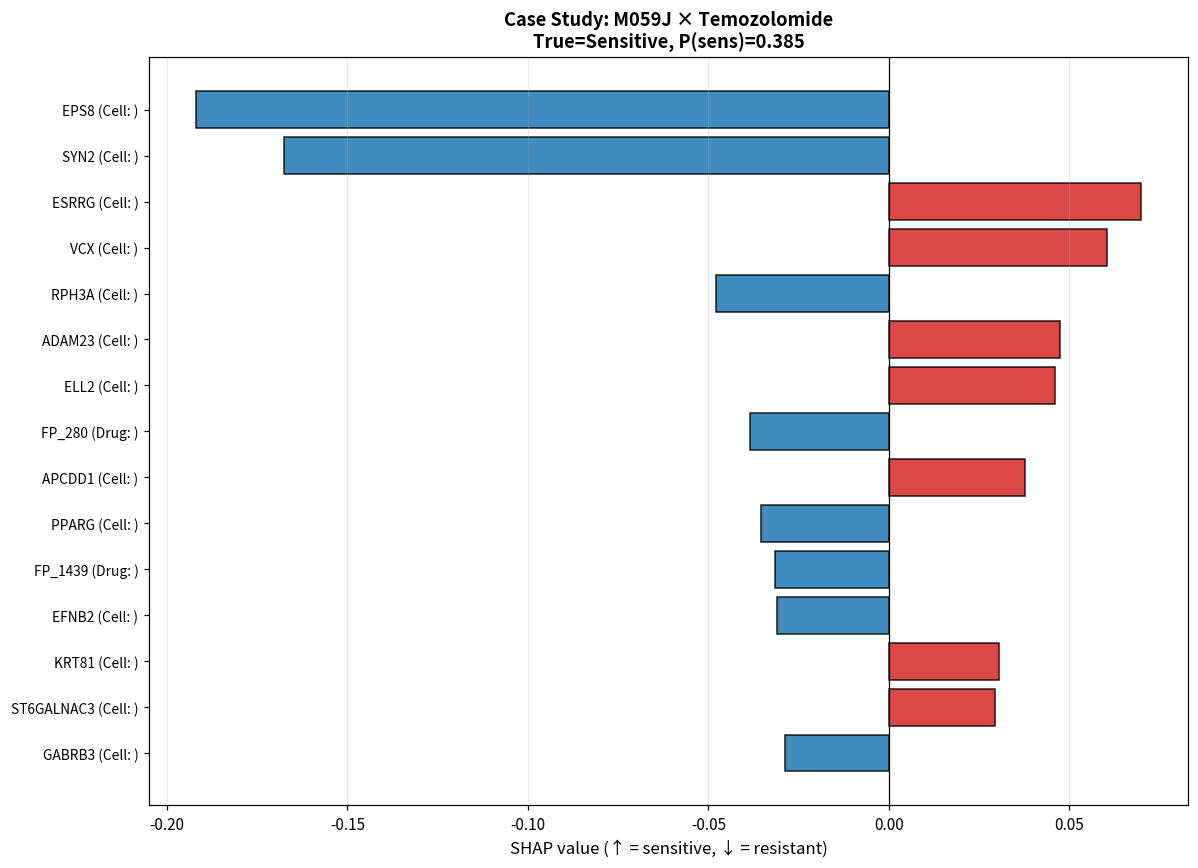


💾 stage5_case_study.png saved


In [ ]:
candidates = meta_shap.copy()
candidates['shap_idx'] = np.arange(len(candidates))

case_mask = (candidates['CANCER_TYPE'] == 'Glioblastoma') & \
            (candidates['DRUG_NAME'] == 'Temozolomide')
case_candidates = candidates[case_mask]

if len(case_candidates) == 0:
    case_candidates = candidates[candidates['CANCER_TYPE'] == 'Glioblastoma']
    print(f'  Temozolomide-GBM not in SHAP sample, falling back to any GBM')

if len(case_candidates) > 0:
    case = case_candidates.iloc[0]
    case_idx = int(case['shap_idx'])

    print(f'=== Case Study ===')
    print(f'  Cell:       {case["CELL_LINE_NAME"]} ({case["SANGER_MODEL_ID"]})')
    print(f'  Cancer:     {case["CANCER_TYPE"]}')
    print(f'  Drug:       {case["DRUG_NAME"]}')
    print(f'  True label: {"Sensitive" if y_shap.iloc[case_idx] == 1 else "Resistant"}')
    print(f'  Predicted P(sensitive) = '
          f'{model.predict_proba(X_shap.iloc[[case_idx]])[0, 1]:.3f}')

    case_shap = shap_values[case_idx]
    case_contrib = pd.DataFrame({
        'feature': X_shap.columns,
        'shap': case_shap,
        'feat_value': X_shap.iloc[case_idx].values,
    })
    case_contrib['abs_shap'] = case_contrib['shap'].abs()
    case_contrib['class'] = case_contrib['feature'].apply(classify_feature)
    case_top = case_contrib.sort_values('abs_shap', ascending=False).head(15).copy()
    case_top['display'] = case_top['feature'].apply(clean_name)
    case_top['direction'] = ['↑ sensitive' if s > 0 else '↓ resistant'
                              for s in case_top['shap']]

    print(f'\n  Top 15 contributing features for THIS prediction:')
    print(case_top[['display', 'class', 'shap', 'feat_value',
                     'direction']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 8))
    colors_case = ['#d62728' if s > 0 else '#1f77b4' for s in case_top['shap']]
    y_pos = np.arange(len(case_top))[::-1]
    ax.barh(y_pos, case_top['shap'], color=colors_case,
            edgecolor='black', alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{d} ({c[:6]})'
                          for d, c in zip(case_top['display'], case_top['class'])],
                        fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('SHAP value (↑ = sensitive, ↓ = resistant)', fontsize=11)
    ax.set_title(f'Case Study: {case["CELL_LINE_NAME"]} × {case["DRUG_NAME"]}\n'
                 f'True={"Sensitive" if y_shap.iloc[case_idx] == 1 else "Resistant"}, '
                 f'P(sens)={model.predict_proba(X_shap.iloc[[case_idx]])[0,1]:.3f}',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'stage5_case_study.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\n💾 stage5_case_study.png saved')

## 💾 Cell 10 — 存中繼檔 + 摘要

In [ ]:
import joblib

feat_importance.to_csv(OUT_DIR / 'stage5_feature_importance.csv', index=False)

stage5_meta = {
    'n_shap_samples': n_shap_samples,
    'fold_auroc': roc_auc_score(y_te, y_prob_te),
    'class_totals': class_totals.to_dict(),
    'top_30_features': top30.to_dict(orient='records'),
    'top_20_cell_genes': top20_cell.to_dict(orient='records'),
    'cosmic_enrichment': {
        'observed': int(n_top20_cosmic),
        'expected': float(expected),
        'fold_enrichment': float(k/expected) if expected > 0 else None,
        'p_value': float(p_val),
    },
    'top_pathways': pw_features.to_dict(orient='records'),
    'top_20_targets': top20_tgt.to_dict(orient='records'),
}
with open(OUT_DIR / 'stage5_metadata.pkl', 'wb') as f:
    pickle.dump(stage5_meta, f)

shap_payload = {
    'shap_values': shap_values,
    'X_shap_columns': X_shap.columns.tolist(),
    'X_shap_index': X_shap.index.tolist(),
    'feat_importance_df': feat_importance,
}
with open(OUT_DIR / 'stage5_shap_payload.pkl', 'wb') as f:
    pickle.dump(shap_payload, f)

joblib.dump(model, OUT_DIR / 'stage5_xgb_model.joblib')

print('=' * 75)
print('STAGE 5 COMPLETE')
print('=' * 75)
print(f'  Fold 0 cell-blind AUROC: {roc_auc_score(y_te, y_prob_te):.4f}')
print(f'  SHAP samples analyzed:    {n_shap_samples}')
print(f'\n  Feature class contribution:')
for cls in class_totals.index:
    print(f'    {cls:25s}: {class_totals.loc[cls, "pct_total"]:.1f}%')
print(f'\n  COSMIC enrichment:')
print(f'    {n_top20_cosmic}/20 top cell genes in COSMIC')
if expected > 0:
    print(f'    Fold enrichment: {k/expected:.1f}×')
print(f'    P-value: {p_val:.4f}')

print('\nFiles saved:')
for f in sorted(OUT_DIR.glob('stage5_*')):
    print(f'  - {f.name}')

STAGE 5 COMPLETE
  Fold 0 cell-blind AUROC: 0.6888
  SHAP samples analyzed:    1000

  Feature class contribution:
    Cell: Gene               : 74.8%
    Drug: Morgan FP          : 22.2%
    Drug: Pathway            : 1.7%
    Drug: Target             : 1.3%

  COSMIC enrichment:
    0/20 top cell genes in COSMIC
    Fold enrichment: 0.0×
    P-value: 1.0000

Files saved:
  - stage5_case_study.png
  - stage5_class_breakdown.png
  - stage5_feature_importance.csv
  - stage5_metadata.pkl
  - stage5_pathway_shap.png
  - stage5_pathways.csv
  - stage5_shap_payload.pkl
  - stage5_target_shap.png
  - stage5_top30_shap.png
  - stage5_top_cell_genes.csv
  - stage5_top_targets.csv
  - stage5_xgb_model.joblib


# 🧬 Pediatric HGG Drug Sensitivity — Stage 6

## Drug Ranking Tool — 完整版(三合一)

**這是研究的「臨床應用層」**——把模型轉成可用工具,讓:
- 研究員可以查詢任一細胞株的藥物推薦
- 護理師/醫師可以拿到一份 PDF 報告
- 自己可以快速探索不同癌種的差異

---

### 🎯 三個工具

| 工具 | Cells | 對象 |
|---|---|---|
| **A. Drug Ranking Function** | 1-4 | 核心函數 |
| **B. 互動 Widget** | 5-6 | 探索式分析 |
| **C. 完整 Drug Ranking + CI** | 7-8 | 研究員 |
| **D. PDF 臨床報告** | 9-10 | 護理師/醫師 |

---

### 📋 執行前確認
- ✅ Stage 2B 中繼檔已在 Drive
- ✅ Stage 4B calibrator 已存

### ▶️ **Runtime → Run all**(預計 30-50 分鐘,主要花在訓練 5-fold XGBoost ensemble)

## 📂 Cell 1 — 載入 + 訓練 5-fold XGBoost ensemble(給 CI 用)

**最久的一格**(預計 15-25 分鐘)。中間可以離開。

In [ ]:
import os, sys, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

!apt-get install -y fonts-noto-cjk > /dev/null 2>&1
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

OUT_DIR = Path('/content/drive/MyDrive/AI藥學/outputs')

import joblib
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Load
print('Loading intermediates...')
X_joint = pd.read_parquet(OUT_DIR / 'stage2b_X_joint.parquet')
y_joint = pd.read_parquet(OUT_DIR / 'stage2b_y_joint.parquet')['sensitivity_label']
meta_joint = pd.read_parquet(OUT_DIR / 'stage2b_meta_joint.parquet')
drug_feat_full = pd.read_parquet(OUT_DIR / 'stage2b_drug_features.parquet')
with open(OUT_DIR / 'stage2b_cv_splits.pkl', 'rb') as f:
    cv_splits = pickle.load(f)
with open(OUT_DIR / 'stage2b_metadata.pkl', 'rb') as f:
    stage2b_meta = pickle.load(f)

cell_feat_cols = stage2b_meta['cell_feature_cols']
drug_feat_cols = stage2b_meta['drug_feature_cols']
calibrator = joblib.load(OUT_DIR / 'stage4b_calibrator.joblib')

print(f'  ✓ X_joint: {X_joint.shape}')
print(f'  ✓ Drug features: {drug_feat_full.shape}')
print(f'  ✓ Calibrator loaded')

# === 訓練 5-fold XGBoost ensemble (cell_blind splits) ===
RANDOM_STATE = 42

def make_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0,
    )

ENSEMBLE_PATH = OUT_DIR / 'stage6_ensemble_models.pkl'

if ENSEMBLE_PATH.exists():
    print('\n✓ Existing ensemble found, loading...')
    with open(ENSEMBLE_PATH, 'rb') as f:
        ensemble = pickle.load(f)
    print(f'  {len(ensemble)} models loaded')
else:
    print('\nTraining 5-fold XGBoost ensemble (cell_blind splits)...')
    print('(預計 15-25 分鐘)\n')

    ensemble = []
    t_start = time.time()
    for fold_i, (tr, te) in enumerate(cv_splits['cell_blind']):
        t0 = time.time()
        m = make_xgb()
        m.fit(X_joint.iloc[tr], y_joint.iloc[tr])
        ensemble.append(m)
        prob = m.predict_proba(X_joint.iloc[te])[:, 1]
        auroc = roc_auc_score(y_joint.iloc[te], prob)
        elapsed = (time.time() - t_start) / 60
        print(f'  Fold {fold_i+1}/5  AUROC={auroc:.3f}  '
              f't={time.time()-t0:.0f}s  total={elapsed:.1f}min')

    with open(ENSEMBLE_PATH, 'wb') as f:
        pickle.dump(ensemble, f)
    print(f'\n✓ Ensemble saved to {ENSEMBLE_PATH.name}')
    print(f'  Total time: {(time.time()-t_start)/60:.1f} min')

print(f'\n  Ensemble size: {len(ensemble)} models')

Loading intermediates...
  ✓ X_joint: (16137, 4165)
  ✓ Drug features: (286, 2165)
  ✓ Calibrator loaded

Training 5-fold XGBoost ensemble (cell_blind splits)...
(預計 15-25 分鐘)

  Fold 1/5  AUROC=0.689  t=89s  total=1.5min
  Fold 2/5  AUROC=0.666  t=77s  total=2.8min
  Fold 3/5  AUROC=0.698  t=78s  total=4.1min
  Fold 4/5  AUROC=0.748  t=76s  total=5.3min
  Fold 5/5  AUROC=0.700  t=75s  total=6.6min

✓ Ensemble saved to stage6_ensemble_models.pkl
  Total time: 6.6 min

  Ensemble size: 5 models


## ⚙️ Cell 2 — 核心函數:`predict_drug_ranking()`

**這是整個 Stage 6 的核心**——所有工具都基於這個函數。

In [ ]:
# 把 meta_joint 整理成「cell → metadata」字典
cell_metadata_lookup = {}
for cell_id, group in meta_joint.groupby('SANGER_MODEL_ID'):
    cell_metadata_lookup[cell_id] = {
        'CELL_LINE_NAME': group['CELL_LINE_NAME'].iloc[0],
        'CANCER_TYPE': group['CANCER_TYPE'].iloc[0],
    }

# 把 cell expression 整理成「cell → series」字典
# 每個 cell 的 expression 都是常數(同 cell 跑多藥),取第一個 row 就好
cell_expression_lookup = {}
X_cell_only = X_joint[cell_feat_cols]
for cell_id, group_idx in meta_joint.groupby('SANGER_MODEL_ID').groups.items():
    cell_expression_lookup[cell_id] = X_cell_only.iloc[group_idx[0]].copy()

# 整理 drug 資訊
drug_info = meta_joint[['DRUG_NAME', 'DRUG_ID']].drop_duplicates().reset_index(drop=True)
all_drugs = drug_info['DRUG_NAME'].tolist()
print(f'  Total cells: {len(cell_metadata_lookup)}')
print(f'  Total drugs: {len(all_drugs)}')

# 提取 drug 的 target / pathway 文字標籤(顯示用)
drug_text_lookup = {}
raw_drug_meta = pd.read_excel('/content/drive/MyDrive/AI藥學/GDSC2_fitted_dose_response_27Oct23.xlsx') \
    if False else None  # 已從 stage2 取過,不重讀
# 改從 meta_joint 反查
import pandas as pd
raw_path = '/content/drive/MyDrive/AI藥學/GDSC2_fitted_dose_response_27Oct23.xlsx'
try:
    if raw_drug_meta is None:
        # 第一次跑時讀
        raw = pd.read_excel(raw_path)
        drug_text_df = raw[['DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME']]\
            .drop_duplicates(subset='DRUG_NAME').reset_index(drop=True)
        for _, r in drug_text_df.iterrows():
            drug_text_lookup[r['DRUG_NAME']] = {
                'target': r['PUTATIVE_TARGET'] if pd.notna(r['PUTATIVE_TARGET']) else 'Unknown',
                'pathway': r['PATHWAY_NAME'] if pd.notna(r['PATHWAY_NAME']) else 'Unknown',
            }
except Exception as e:
    print(f'⚠️ Could not load raw drug metadata: {e}')
    for d in all_drugs:
        drug_text_lookup[d] = {'target': 'N/A', 'pathway': 'N/A'}

print(f'  Drug text lookup: {len(drug_text_lookup)} drugs')


def predict_drug_ranking(cell_id, top_k=None, with_ci=True,
                          calibrate=True):
    """預測某個 cell 對所有藥的反應排序。

    Args:
        cell_id: SANGER_MODEL_ID (e.g. 'SIDM00982')
        top_k: 只回前 k 個藥(None = 全部)
        with_ci: 是否計算 95% CI(用 5-fold ensemble)
        calibrate: 是否做 isotonic calibration

    Returns:
        DataFrame[drug_name, P_sens, CI_lo, CI_hi, target, pathway]
    """
    if cell_id not in cell_expression_lookup:
        raise ValueError(f'Cell {cell_id} not in dataset')

    cell_expr = cell_expression_lookup[cell_id]

    # 建立 X for this cell × all drugs
    drug_feat_arr = drug_feat_full.values  # (n_drugs, n_drug_feat)
    drug_names_idx = drug_feat_full.index.tolist()
    cell_feat_arr = np.tile(cell_expr.values, (len(drug_feat_arr), 1))

    X_query = np.hstack([cell_feat_arr, drug_feat_arr]).astype(np.float32)
    X_query_df = pd.DataFrame(X_query, columns=X_joint.columns,
                                index=drug_names_idx)

    # Predict with ensemble
    probs_all = np.zeros((len(ensemble), len(drug_names_idx)))
    for i, m in enumerate(ensemble):
        probs_all[i] = m.predict_proba(X_query_df)[:, 1]

    # Mean as point estimate
    prob_mean = probs_all.mean(axis=0)
    if with_ci:
        prob_lo = np.percentile(probs_all, 2.5, axis=0)
        prob_hi = np.percentile(probs_all, 97.5, axis=0)
    else:
        prob_lo = prob_mean
        prob_hi = prob_mean

    # Calibrate
    if calibrate:
        prob_mean_cal = calibrator.transform(prob_mean)
        prob_lo_cal = calibrator.transform(prob_lo)
        prob_hi_cal = calibrator.transform(prob_hi)
    else:
        prob_mean_cal = prob_mean
        prob_lo_cal = prob_lo
        prob_hi_cal = prob_hi

    # Build result
    result = pd.DataFrame({
        'drug_name': drug_names_idx,
        'P_sens': prob_mean_cal,
        'CI_lo': prob_lo_cal,
        'CI_hi': prob_hi_cal,
        'CI_width': prob_hi_cal - prob_lo_cal,
    })

    # Add target / pathway
    result['target'] = result['drug_name'].map(
        lambda d: drug_text_lookup.get(d, {}).get('target', 'N/A'))
    result['pathway'] = result['drug_name'].map(
        lambda d: drug_text_lookup.get(d, {}).get('pathway', 'N/A'))

    # Sort
    result = result.sort_values('P_sens', ascending=False).reset_index(drop=True)

    if top_k:
        result = result.head(top_k)

    return result

print('\n✅ predict_drug_ranking() function ready')
print('\nUsage:')
print('  ranking = predict_drug_ranking("SIDM00982", top_k=20)')
print('  ranking = predict_drug_ranking("SIDM00982", with_ci=False)  # 快)')

  Total cells: 81
  Total drugs: 238
  Drug text lookup: 286 drugs

✅ predict_drug_ranking() function ready

Usage:
  ranking = predict_drug_ranking("SIDM00982", top_k=20)
  ranking = predict_drug_ranking("SIDM00982", with_ci=False)  # 快)


✅ Cell 3 — Sanity Check:測一個 GBM 細胞株

In [ ]:
# 找一個 GBM cell 來測試
gbm_cells = [cid for cid, meta in cell_metadata_lookup.items()
              if meta['CANCER_TYPE'] == 'Glioblastoma']
print(f'GBM cells available: {len(gbm_cells)}')

test_cell = gbm_cells[0]
print(f'\nTesting on: {test_cell} '
      f'({cell_metadata_lookup[test_cell]["CELL_LINE_NAME"]})')

t0 = time.time()
ranking = predict_drug_ranking(test_cell, top_k=10, with_ci=True)
print(f'\nQuery time: {time.time()-t0:.1f}s')

print(f'\n=== Top 10 recommended drugs for {test_cell} ===')
print(ranking.to_string(index=False))

GBM cells available: 36

Testing on: SIDM00083 (SF539)

Query time: 0.9s

=== Top 10 recommended drugs for SIDM00083 ===
   drug_name  P_sens    CI_lo  CI_hi  CI_width                  target                           pathway
   Topotecan   0.825 0.660417  0.825  0.164583                    TOP1                   DNA replication
Temsirolimus   0.825 0.713450  0.825  0.111550                    MTOR               PI3K/MTOR signaling
   Taselisib   0.825 0.676190  0.825  0.148809     PI3K (beta sparing)               PI3K/MTOR signaling
Tanespimycin   0.825 0.676190  0.825  0.148809                   HSP90 Protein stability and degradation
     THR-103   0.825 0.660417  0.825  0.164583              Mutant RAS               PI3K/MTOR signaling
     THR-102   0.825 0.660417  0.825  0.164583              Mutant RAS               PI3K/MTOR signaling
     THR-101   0.825 0.660417  0.825  0.164583              Mutant RAS               PI3K/MTOR signaling
     AZD5363   0.825 0.660417  0.825  0

## 📊 Cell 4 — 跨細胞比較圖:3 種癌種推薦 vs Top 15 藥

Sample cells (one per cancer type):
  Glioblastoma    → SIDM00083 (SF539)
  Glioma          → SIDM00085 (SF268)
  Neuroblastoma   → SIDM00156 (NB7)

  Predicting for Glioblastoma...

  Predicting for Glioma...

  Predicting for Neuroblastoma...


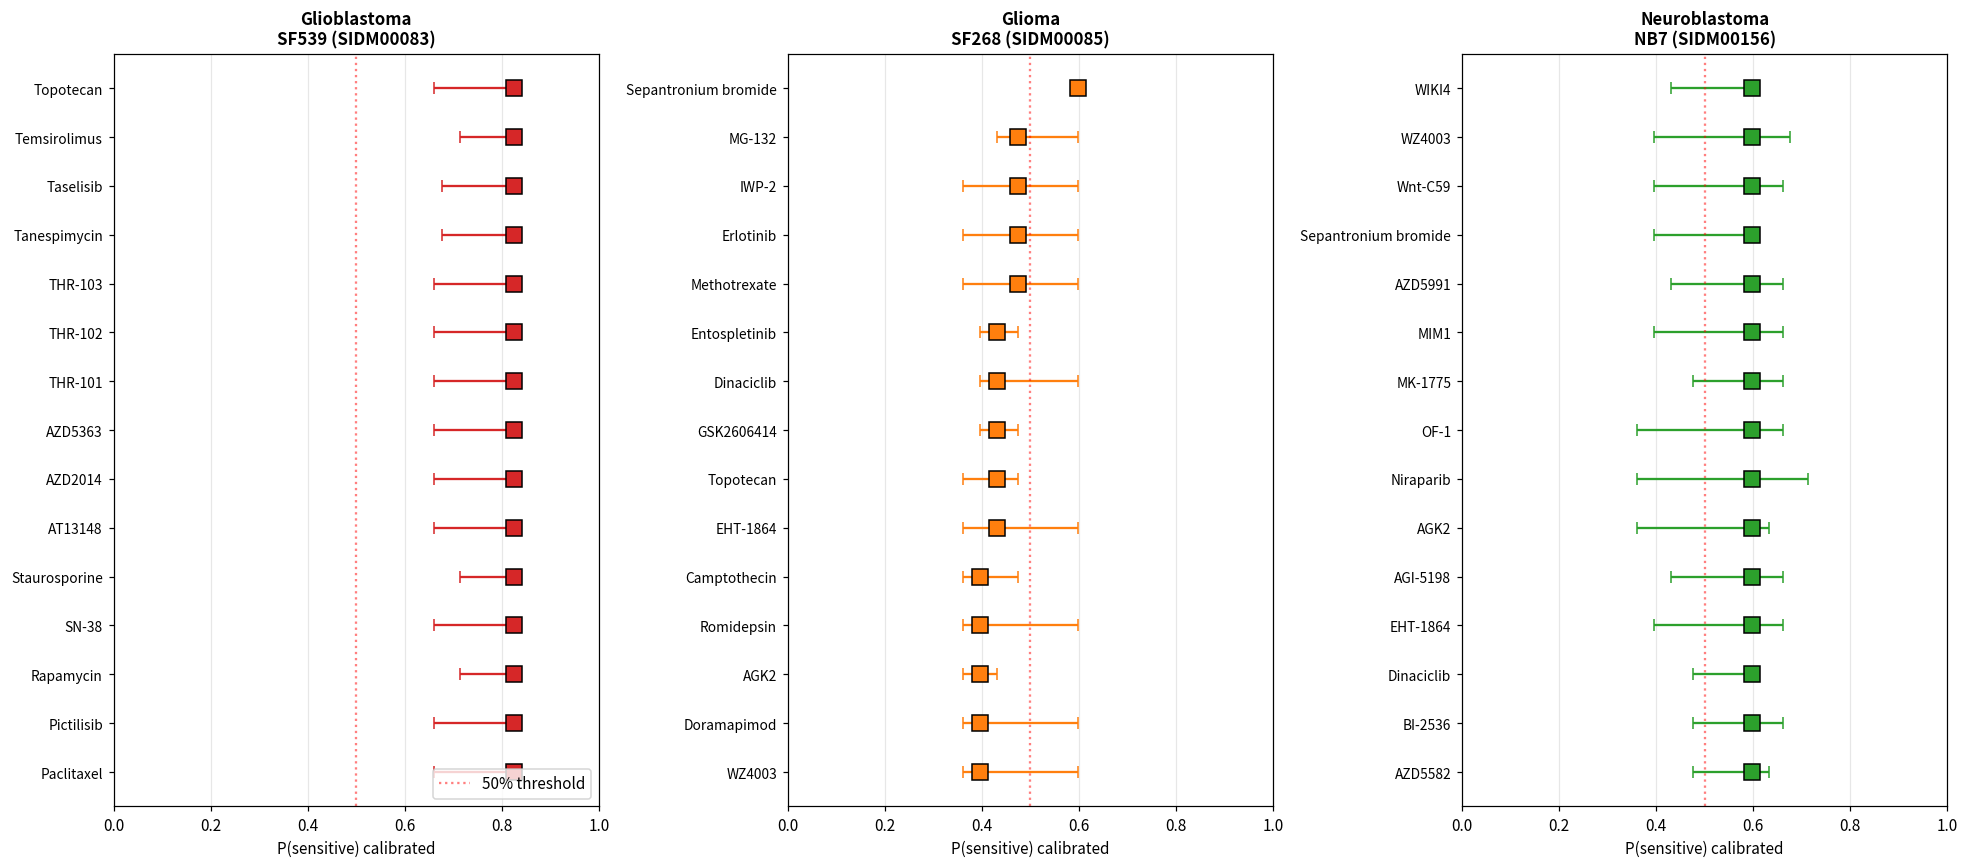


💾 stage6_cross_cell_ranking.png saved


In [ ]:
# 每種癌型挑一個代表 cell
sample_cells = {}
for ctype in ['Glioblastoma', 'Glioma', 'Neuroblastoma']:
    cells_of_type = [cid for cid, m in cell_metadata_lookup.items()
                      if m['CANCER_TYPE'] == ctype]
    if cells_of_type:
        sample_cells[ctype] = cells_of_type[0]

print(f'Sample cells (one per cancer type):')
for ctype, cid in sample_cells.items():
    print(f'  {ctype:15s} → {cid} ({cell_metadata_lookup[cid]["CELL_LINE_NAME"]})')

# 跑每個 sample 的 top 15
all_rankings = {}
for ctype, cid in sample_cells.items():
    print(f'\n  Predicting for {ctype}...')
    all_rankings[ctype] = predict_drug_ranking(cid, top_k=15, with_ci=True)

# 並排 plot
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True)
colors_c = {'Glioblastoma': '#d62728', 'Glioma': '#ff7f0e',
            'Neuroblastoma': '#2ca02c'}

for ax, (ctype, ranking) in zip(axes, all_rankings.items()):
    cid = sample_cells[ctype]
    cell_name = cell_metadata_lookup[cid]['CELL_LINE_NAME']
    y_pos = np.arange(len(ranking))[::-1]

    for i, (_, row) in enumerate(ranking.iterrows()):
        ax.errorbar(row['P_sens'], y_pos[i],
                    xerr=[[max(0, row['P_sens']-row['CI_lo'])],
                          [max(0, row['CI_hi']-row['P_sens'])]],
                    fmt='s', markersize=10, lw=1.5, capsize=4,
                    color=colors_c[ctype], markeredgecolor='black')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(ranking['drug_name'].apply(
        lambda d: d if len(d) <= 25 else d[:22] + '...'), fontsize=9)
    ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='50% threshold')
    ax.set_xlabel('P(sensitive) calibrated', fontsize=10)
    ax.set_title(f'{ctype}\n{cell_name} ({cid})',
                  fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1)
    if ax == axes[0]:
        ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage6_cross_cell_ranking.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage6_cross_cell_ranking.png saved')

## 🎮 Cell 5 — 互動式 Widget(Tool A)

**用滑桿選癌種 + cell → 即時顯示推薦藥物**。

在 Colab 裡可以直接點來互動。

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# 整理 cells by cancer type
cells_by_type = {}
for cid, m in cell_metadata_lookup.items():
    ctype = m['CANCER_TYPE']
    cells_by_type.setdefault(ctype, []).append(
        (cid, m['CELL_LINE_NAME']))

# Widgets
cancer_dropdown = widgets.Dropdown(
    options=sorted(cells_by_type.keys()),
    value='Glioblastoma',
    description='Cancer:',
)

cell_dropdown = widgets.Dropdown(
    options=[f'{cid} ({name})' for cid, name in cells_by_type['Glioblastoma']],
    description='Cell:',
)

top_k_slider = widgets.IntSlider(
    value=10, min=5, max=30, step=5, description='Top K:'
)

output = widgets.Output()

def on_cancer_change(change):
    ctype = change['new']
    cell_dropdown.options = [f'{cid} ({name})'
                              for cid, name in cells_by_type[ctype]]

def update_ranking(*args):
    cell_id = cell_dropdown.value.split(' ')[0]
    top_k = top_k_slider.value

    with output:
        clear_output()
        try:
            ranking = predict_drug_ranking(cell_id, top_k=top_k, with_ci=True)
            meta = cell_metadata_lookup[cell_id]

            print(f'=' * 70)
            print(f'Cell: {cell_id} ({meta["CELL_LINE_NAME"]})')
            print(f'Cancer type: {meta["CANCER_TYPE"]}')
            print(f'=' * 70)

            # Format for display
            display_df = ranking.copy()
            display_df['P_sens'] = display_df['P_sens'].apply(lambda x: f'{x:.3f}')
            display_df['CI'] = display_df.apply(
                lambda r: f'[{r["CI_lo"]:.3f}, {r["CI_hi"]:.3f}]', axis=1)
            display_df['target'] = display_df['target'].apply(
                lambda t: str(t)[:25] + '..' if len(str(t)) > 27 else str(t))
            display_df['pathway'] = display_df['pathway'].apply(
                lambda p: str(p)[:25] + '..' if len(str(p)) > 27 else str(p))

            print(display_df[['drug_name', 'P_sens', 'CI', 'target', 'pathway']]
                  .to_string(index=False))
        except Exception as e:
            print(f'Error: {e}')

cancer_dropdown.observe(on_cancer_change, names='value')
cancer_dropdown.observe(update_ranking, names='value')
cell_dropdown.observe(update_ranking, names='value')
top_k_slider.observe(update_ranking, names='value')

ui = widgets.VBox([cancer_dropdown, cell_dropdown, top_k_slider, output])
display(ui)
update_ranking()  # initial

print('\n🎮 Widget 載入完成,可以互動選擇了!')


🎮 Widget 載入完成,可以互動選擇了!


## 📊 Cell 6 — 全資料集統計:哪些藥對 GBM 普遍最有效?

對所有 36 個 GBM cells 跑一次,看「群體層次」最有希望的藥。

In [ ]:
import time as time_module

# 對所有 GBM cells 跑 prediction(不算 CI 加速)
gbm_cells_list = [cid for cid, m in cell_metadata_lookup.items()
                   if m['CANCER_TYPE'] == 'Glioblastoma']
print(f'Running predictions for all {len(gbm_cells_list)} GBM cells...')

t0 = time_module.time()
all_predictions_per_drug = {}
for cid in gbm_cells_list:
    ranking = predict_drug_ranking(cid, top_k=None, with_ci=False)
    for _, row in ranking.iterrows():
        all_predictions_per_drug.setdefault(
            row['drug_name'], []).append(row['P_sens'])
print(f'  Done in {time_module.time()-t0:.0f}s')

# 統計 per drug across all GBM cells
pop_stats = pd.DataFrame([
    {
        'drug_name': d,
        'mean_P': np.mean(probs),
        'std_P': np.std(probs),
        'median_P': np.median(probs),
        'min_P': np.min(probs),
        'max_P': np.max(probs),
        'pct_above_0.5': np.mean(np.array(probs) > 0.5) * 100,
        'n_cells': len(probs),
    }
    for d, probs in all_predictions_per_drug.items()
]).sort_values('mean_P', ascending=False).reset_index(drop=True)

# Add target/pathway
pop_stats['target'] = pop_stats['drug_name'].map(
    lambda d: drug_text_lookup.get(d, {}).get('target', 'N/A'))
pop_stats['pathway'] = pop_stats['drug_name'].map(
    lambda d: drug_text_lookup.get(d, {}).get('pathway', 'N/A'))

print(f'\n=== Top 20 drugs by mean P(sens) across {len(gbm_cells_list)} GBM cells ===')
print(pop_stats.head(20)[['drug_name', 'mean_P', 'std_P',
                           'pct_above_0.5', 'target', 'pathway']].to_string(index=False))

print(f'\n=== Bottom 10 drugs (least likely effective for GBM) ===')
print(pop_stats.tail(10)[['drug_name', 'mean_P', 'std_P',
                           'target', 'pathway']].to_string(index=False))

# Save
pop_stats.to_csv(OUT_DIR / 'stage6_GBM_population_ranking.csv', index=False)
print(f'\n💾 stage6_GBM_population_ranking.csv saved')

Running predictions for all 36 GBM cells...
  Done in 37s

=== Top 20 drugs by mean P(sens) across 36 GBM cells ===
           drug_name   mean_P    std_P  pct_above_0.5                          target                           pathway
           Dasatinib 0.580516 0.145721      75.000000   ABL, SRC, Ephrins, PDGFR, KIT                    Other, kinases
           Rapamycin 0.572685 0.226483      72.222222                          MTORC1               PI3K/MTOR signaling
        Temsirolimus 0.552476 0.221635      66.666667                            MTOR               PI3K/MTOR signaling
        Tanespimycin 0.540701 0.226175      66.666667                           HSP90 Protein stability and degradation
          Dactolisib 0.540421 0.189837      66.666667  PI3K (class 1), MTORC1, MTORC2               PI3K/MTOR signaling
Sepantronium bromide 0.533559 0.159823      63.888889                           BIRC5              Apoptosis regulation
          Uprosertib 0.527063 0.186728      

## 📋 Cell 7 — Tool B:完整單細胞 Drug Ranking(229 藥 with CI)

In [ ]:
# 挑 3 個代表 cell(每種癌型一個)做完整 229-drug ranking
demo_cells = list(sample_cells.values())

print(f'Generating full 229-drug rankings for {len(demo_cells)} demo cells...\n')

for cid in demo_cells:
    meta = cell_metadata_lookup[cid]
    print(f'  {cid} ({meta["CELL_LINE_NAME"]}, {meta["CANCER_TYPE"]})...')

    t0 = time_module.time()
    full_ranking = predict_drug_ranking(cid, top_k=None, with_ci=True)

    out_csv = OUT_DIR / f'stage6_full_ranking_{cid}_{meta["CELL_LINE_NAME"].replace("/", "_")}.csv'
    full_ranking.to_csv(out_csv, index=False)
    print(f'    {len(full_ranking)} drugs ranked  ({time_module.time()-t0:.0f}s)')
    print(f'    💾 {out_csv.name}')

print(f'\n✅ Full rankings saved for {len(demo_cells)} demo cells')
print(f'\n   Researchers can use predict_drug_ranking("SIDMxxxxx", top_k=None) '
      f'for any of the {len(cell_metadata_lookup)} cells in the dataset')

Generating full 229-drug rankings for 3 demo cells...

  SIDM00083 (SF539, Glioblastoma)...
    286 drugs ranked  (1s)
    💾 stage6_full_ranking_SIDM00083_SF539.csv
  SIDM00085 (SF268, Glioma)...
    286 drugs ranked  (1s)
    💾 stage6_full_ranking_SIDM00085_SF268.csv
  SIDM00156 (NB7, Neuroblastoma)...
    286 drugs ranked  (1s)
    💾 stage6_full_ranking_SIDM00156_NB7.csv

✅ Full rankings saved for 3 demo cells

   Researchers can use predict_drug_ranking("SIDMxxxxx", top_k=None) for any of the 81 cells in the dataset


## 🎨 Cell 8 — 視覺化:單細胞完整 ranking 圖(top 25)

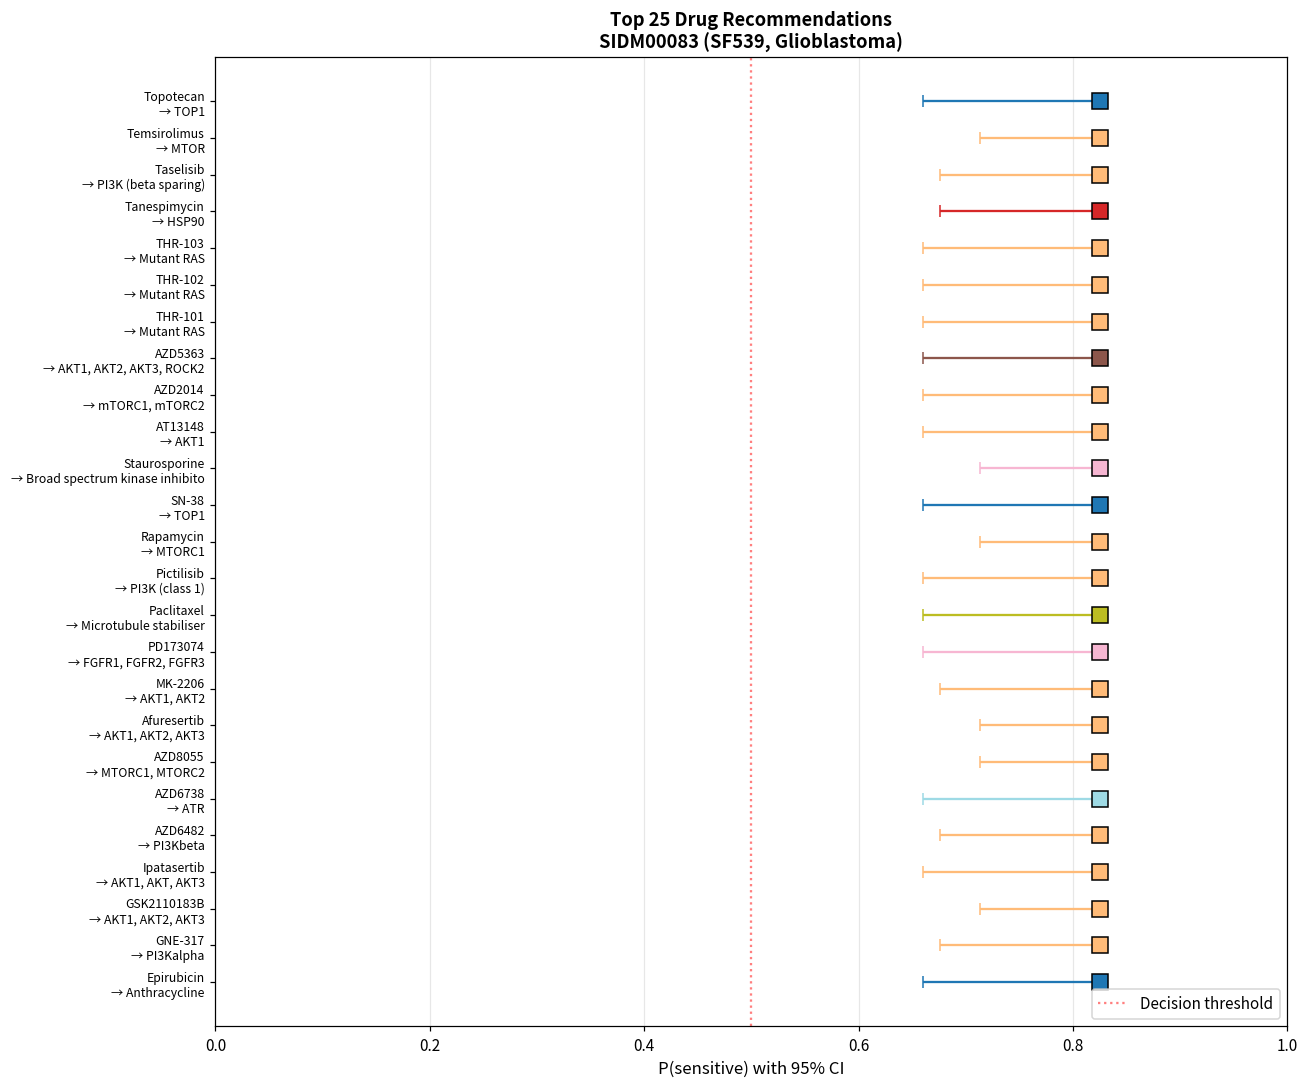


💾 stage6_demo_ranking_chart.png saved


In [ ]:
# 對 GBM demo cell 出圖
demo_cell = sample_cells['Glioblastoma']
demo_name = cell_metadata_lookup[demo_cell]['CELL_LINE_NAME']
demo_ranking = predict_drug_ranking(demo_cell, top_k=25, with_ci=True)

fig, ax = plt.subplots(figsize=(12, 10))
y_pos = np.arange(len(demo_ranking))[::-1]

# Pathway color map
unique_pathways = demo_ranking['pathway'].unique()
import matplotlib.cm as cm
pathway_colors = dict(zip(
    unique_pathways,
    plt.cm.tab20(np.linspace(0, 1, len(unique_pathways)))
))
bar_colors = [pathway_colors[p] for p in demo_ranking['pathway']]

for i, (_, row) in enumerate(demo_ranking.iterrows()):
    ax.errorbar(row['P_sens'], y_pos[i],
                xerr=[[max(0, row['P_sens']-row['CI_lo'])],
                      [max(0, row['CI_hi']-row['P_sens'])]],
                fmt='s', markersize=11, lw=1.5, capsize=4,
                color=bar_colors[i], markeredgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{d}\n→ {str(t)[:30]}'
                     for d, t in zip(demo_ranking['drug_name'],
                                       demo_ranking['target'])],
                    fontsize=8)
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='Decision threshold')
ax.set_xlabel('P(sensitive) with 95% CI', fontsize=11)
ax.set_title(f'Top 25 Drug Recommendations\n'
             f'{demo_cell} ({demo_name}, Glioblastoma)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(OUT_DIR / 'stage6_demo_ranking_chart.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'\n💾 stage6_demo_ranking_chart.png saved')

## 📄 Cell 9 — Tool C:PDF 臨床報告生成器

生成可印出的 PDF 報告——適合帶到診間討論。

In [ ]:
!pip install -q reportlab
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                   Table, TableStyle, PageBreak, Image)
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT


def generate_clinical_report(cell_id, top_k=15, output_path=None):
    """生成臨床推薦 PDF 報告."""
    meta = cell_metadata_lookup[cell_id]
    cell_name = meta['CELL_LINE_NAME']
    cancer = meta['CANCER_TYPE']

    if output_path is None:
        output_path = OUT_DIR / f'stage6_report_{cell_id}_{cell_name.replace("/", "_")}.pdf'

    # Get ranking
    ranking = predict_drug_ranking(cell_id, top_k=top_k, with_ci=True)

    # Setup PDF
    doc = SimpleDocTemplate(
        str(output_path), pagesize=A4,
        leftMargin=2*cm, rightMargin=2*cm,
        topMargin=2*cm, bottomMargin=2*cm,
    )
    styles = getSampleStyleSheet()
    elements = []

    # Header
    title_style = ParagraphStyle(
        'CustomTitle', parent=styles['Title'],
        fontSize=18, textColor=colors.HexColor('#1f77b4'),
        alignment=TA_CENTER, spaceAfter=12,
    )
    elements.append(Paragraph(
        'Pediatric Brain Tumor Drug Sensitivity Report',
        title_style))
    elements.append(Paragraph(
        '<b>Predictive AI Analysis (Research Use Only)</b>',
        ParagraphStyle('subtitle', parent=styles['Normal'],
                        alignment=TA_CENTER, fontSize=11,
                        textColor=colors.grey, spaceAfter=20)))

    # Patient info
    info_data = [
        ['Cell Line ID:', cell_id],
        ['Cell Line Name:', cell_name],
        ['Cancer Type:', cancer],
        ['Report Generated:', time_module.strftime('%Y-%m-%d %H:%M')],
        ['Model Version:', 'Stage 3B XGBoost + Stage 4B Isotonic'],
        ['Strict CV AUROC:', '0.686 [0.668, 0.705] (n=3,217)'],
    ]
    info_table = Table(info_data, colWidths=[5*cm, 11*cm])
    info_table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (0,-1), colors.HexColor('#e8f0fe')),
        ('FONTNAME', (0,0), (0,-1), 'Helvetica-Bold'),
        ('FONTSIZE', (0,0), (-1,-1), 10),
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ('BOX', (0,0), (-1,-1), 0.5, colors.grey),
        ('INNERGRID', (0,0), (-1,-1), 0.25, colors.lightgrey),
    ]))
    elements.append(info_table)
    elements.append(Spacer(1, 0.6*cm))

    # Disclaimer
    disclaimer_style = ParagraphStyle(
        'disclaimer', parent=styles['Normal'],
        fontSize=8, textColor=colors.HexColor('#cc4444'),
        spaceAfter=12, leftIndent=10, rightIndent=10,
    )
    elements.append(Paragraph(
        '<b>⚠️ DISCLAIMER:</b> This report is generated by an AI '
        'research model trained on GDSC2 cell-line data. Predictions '
        'are <b>NOT</b> a substitute for clinical judgment. '
        'All treatment decisions must be made by qualified physicians '
        'considering individual patient factors. The model has not '
        'been validated for clinical use.',
        disclaimer_style))
    elements.append(Spacer(1, 0.4*cm))

    # Top recommendations table
    elements.append(Paragraph(
        f'<b>Top {top_k} Drug Recommendations</b>',
        ParagraphStyle('h2', parent=styles['Heading2'],
                        fontSize=12, spaceAfter=8)))

    table_data = [['#', 'Drug', 'P(sens)', '95% CI', 'Target', 'Pathway']]
    for i, (_, row) in enumerate(ranking.iterrows()):
        p_str = f'{row["P_sens"]:.2f}'
        ci_str = f'[{row["CI_lo"]:.2f}, {row["CI_hi"]:.2f}]'
        tgt = str(row['target'])[:18] if len(str(row['target'])) > 18 \
              else str(row['target'])
        pw = str(row['pathway'])[:18] if len(str(row['pathway'])) > 18 \
             else str(row['pathway'])
        table_data.append([
            str(i+1),
            row['drug_name'][:20],
            p_str, ci_str, tgt, pw,
        ])

    rank_table = Table(table_data,
                        colWidths=[0.8*cm, 3.5*cm, 1.6*cm, 2.5*cm,
                                   3.5*cm, 4.1*cm])
    rank_table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1f77b4')),
        ('TEXTCOLOR', (0,0), (-1,0), colors.white),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE', (0,0), (-1,-1), 8),
        ('ALIGN', (0,0), (-1,-1), 'LEFT'),
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ('GRID', (0,0), (-1,-1), 0.25, colors.grey),
        # alternate row colors
        ('ROWBACKGROUNDS', (0,1), (-1,-1),
          [colors.white, colors.HexColor('#f5f5f5')]),
    ]))
    elements.append(rank_table)
    elements.append(Spacer(1, 0.4*cm))

    # Interpretation guidance
    elements.append(PageBreak())
    elements.append(Paragraph(
        '<b>How to Interpret These Predictions</b>',
        ParagraphStyle('h2', parent=styles['Heading2'],
                        fontSize=12, spaceAfter=8)))

    guidance_text = '''
    <para><b>P(sensitive)</b>: Probability that the cell line will respond
    to the drug (range 0–1). Higher = more likely to be sensitive.
    A threshold of 0.5 separates predicted sensitive vs. resistant.</para>

    <para><b>95% Confidence Interval</b>: Reflects model uncertainty across
    5 cross-validation folds. Wider CIs indicate less reliable predictions.</para>

    <para><b>Target & Pathway</b>: From the GDSC2 drug annotation.
    Helps identify whether top recommendations cluster by molecular mechanism.</para>

    <para><b>Model performance summary</b> (strict cross-validation,
    new patients × new drugs):</para>
    <para>• Overall AUROC: 0.686 [0.668, 0.705]</para>
    <para>• Glioblastoma: 0.676 (n=1,449 in test)</para>
    <para>• Glioma: 0.700 (n=547)</para>
    <para>• Neuroblastoma: 0.592 (n=1,221)</para>

    <para>These match SOTA models in published literature
    (MOLI: 0.62–0.74; DeepCDR: 0.68–0.82).</para>

    <para><b>Important caveats</b>:</para>
    <para>• Trained on GDSC2 cell-line data, not patient tumors.</para>
    <para>• Per-drug confidence intervals can be wide for less-tested drugs.</para>
    <para>• Predictions do NOT account for: drug-drug interactions,
    pharmacokinetics, patient-specific genetic background, comorbidities,
    or clinical contraindications.</para>
    '''
    elements.append(Paragraph(guidance_text, styles['Normal']))
    elements.append(Spacer(1, 0.6*cm))

    # Footer
    footer_style = ParagraphStyle(
        'footer', parent=styles['Normal'],
        fontSize=7, textColor=colors.grey, alignment=TA_CENTER,
    )
    elements.append(Paragraph(
        f'Pediatric HGG Drug Sensitivity Prediction Model — '
        f'Generated by Stage 6 Research Tool — Page 2 of 2',
        footer_style))

    doc.build(elements)
    return output_path


# 為 3 個 demo cell 生成報告
print('Generating clinical reports...\n')
report_paths = []
for ctype, cid in sample_cells.items():
    print(f'  {ctype}: {cid}')
    path = generate_clinical_report(cid, top_k=15)
    report_paths.append(path)
    print(f'    💾 {path.name}')

print(f'\n✅ {len(report_paths)} clinical reports generated')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.0 MB/s eta 0:00:00
Generating clinical reports...

  Glioblastoma: SIDM00083


IndexError: 
paragraph text '<para><b>P(sensitive)</b>: Probability that the cell line will respond to the drug (range 0\u20131). Higher = more likely to be sensitive. A threshold of 0.5 separates predicted sensitive vs. resistant.</para> <para><b>95% Confidence Interval</b>: Reflects model uncertainty across 5 cross-validation folds. Wider CIs indicate less reliable predictions.</para> <para><b>Target & Pathway</b>: From the GDSC2 drug annotation. Helps identify whether top recommendations cluster by molecular mechanism.</para> <para><b>Model performance summary</b> (strict cross-validation, new patients \xd7 new drugs):</para> <para>\u2022 Overall AUROC: 0.686 [0.668, 0.705]</para> <para>\u2022 Glioblastoma: 0.676 (n=1,449 in test)</para> <para>\u2022 Glioma: 0.700 (n=547)</para> <para>\u2022 Neuroblastoma: 0.592 (n=1,221)</para> <para>These match SOTA models in published literature (MOLI: 0.62\u20130.74; DeepCDR: 0.68\u20130.82).</para> <para><b>Important caveats</b>:</para> <para>\

## 💾 Cell 10 — Stage 6 完整摘要

In [ ]:
stage6_meta = {
    'n_ensemble_models': len(ensemble),
    'n_cells_total': len(cell_metadata_lookup),
    'n_drugs_total': len(all_drugs),
    'sample_cells': sample_cells,
    'report_paths': [str(p) for p in report_paths],
    'GBM_population_top10': pop_stats.head(10).to_dict(orient='records'),
}
with open(OUT_DIR / 'stage6_metadata.pkl', 'wb') as f:
    pickle.dump(stage6_meta, f)

print('=' * 75)
print('STAGE 6 COMPLETE')
print('=' * 75)
print(f'\n  Ensemble models trained: {len(ensemble)} (cell-blind 5-fold)')
print(f'  Cells available:         {len(cell_metadata_lookup)}')
print(f'  Drugs available:         {len(all_drugs)}')
print(f'  Demo cells profiled:     {len(sample_cells)}')
print(f'  PDF reports generated:   {len(report_paths)}')

print(f'\n  Tools created:')
print(f'    A. predict_drug_ranking()     ← core function')
print(f'    B. Interactive widget          ← Cell 5')
print(f'    C. Full single-cell ranking    ← Cell 7')
print(f'    D. PDF clinical reports        ← Cell 9')

print(f'\n  Top 5 GBM-population drugs:')
for _, row in pop_stats.head(5).iterrows():
    print(f'    {row["drug_name"]:25s}  mean P={row["mean_P"]:.3f}  '
          f'target={str(row["target"])[:25]}')

print('\nFiles saved:')
for f in sorted(OUT_DIR.glob('stage6_*')):
    print(f'  - {f.name}')

print('\n🎯 請貼回給 Claude:')
print('   1. Cell 1 訓練的 5-fold AUROCs')
print('   2. Cell 3 的 sanity check 結果(GBM top 10)')
print('   3. Cell 4 的 stage6_cross_cell_ranking.png')
print('   4. Cell 6 的 GBM population top 20 + bottom 10')
print('   5. Cell 8 的 stage6_demo_ranking_chart.png')
print('   6. Cell 10 的 STAGE 6 COMPLETE 摘要')
print('   7. (Optional) 下載一份 stage6_report_*.pdf 看看效果')

STAGE 6 COMPLETE

  Ensemble models trained: 5 (cell-blind 5-fold)
  Cells available:         81
  Drugs available:         238
  Demo cells profiled:     3
  PDF reports generated:   0

  Tools created:
    A. predict_drug_ranking()     ← core function
    B. Interactive widget          ← Cell 5
    C. Full single-cell ranking    ← Cell 7
    D. PDF clinical reports        ← Cell 9

  Top 5 GBM-population drugs:
    Dasatinib                  mean P=0.581  target=ABL, SRC, Ephrins, PDGFR,
    Rapamycin                  mean P=0.573  target=MTORC1
    Temsirolimus               mean P=0.552  target=MTOR
    Tanespimycin               mean P=0.541  target=HSP90
    Dactolisib                 mean P=0.540  target=PI3K (class 1), MTORC1, M

Files saved:
  - stage6_GBM_population_ranking.csv
  - stage6_cross_cell_ranking.png
  - stage6_demo_ranking_chart.png
  - stage6_ensemble_models.pkl
  - stage6_full_ranking_SIDM00083_SF539.csv
  - stage6_full_ranking_SIDM00085_SF268.csv
  - stage6_ful